# **SQL Basics**

1. Create a table called employees with the following structure?

: emp_id (integer, should not be NULL and should be a primary key).

: emp_name (text, should not be NULL).

: age (integer, should have a check constraint to ensure the age is at least 18).

: email (text, should be unique for each employee).

: salary (decimal, with a default value of 30,000).

Write the SQL query to create the above table with all constraints.

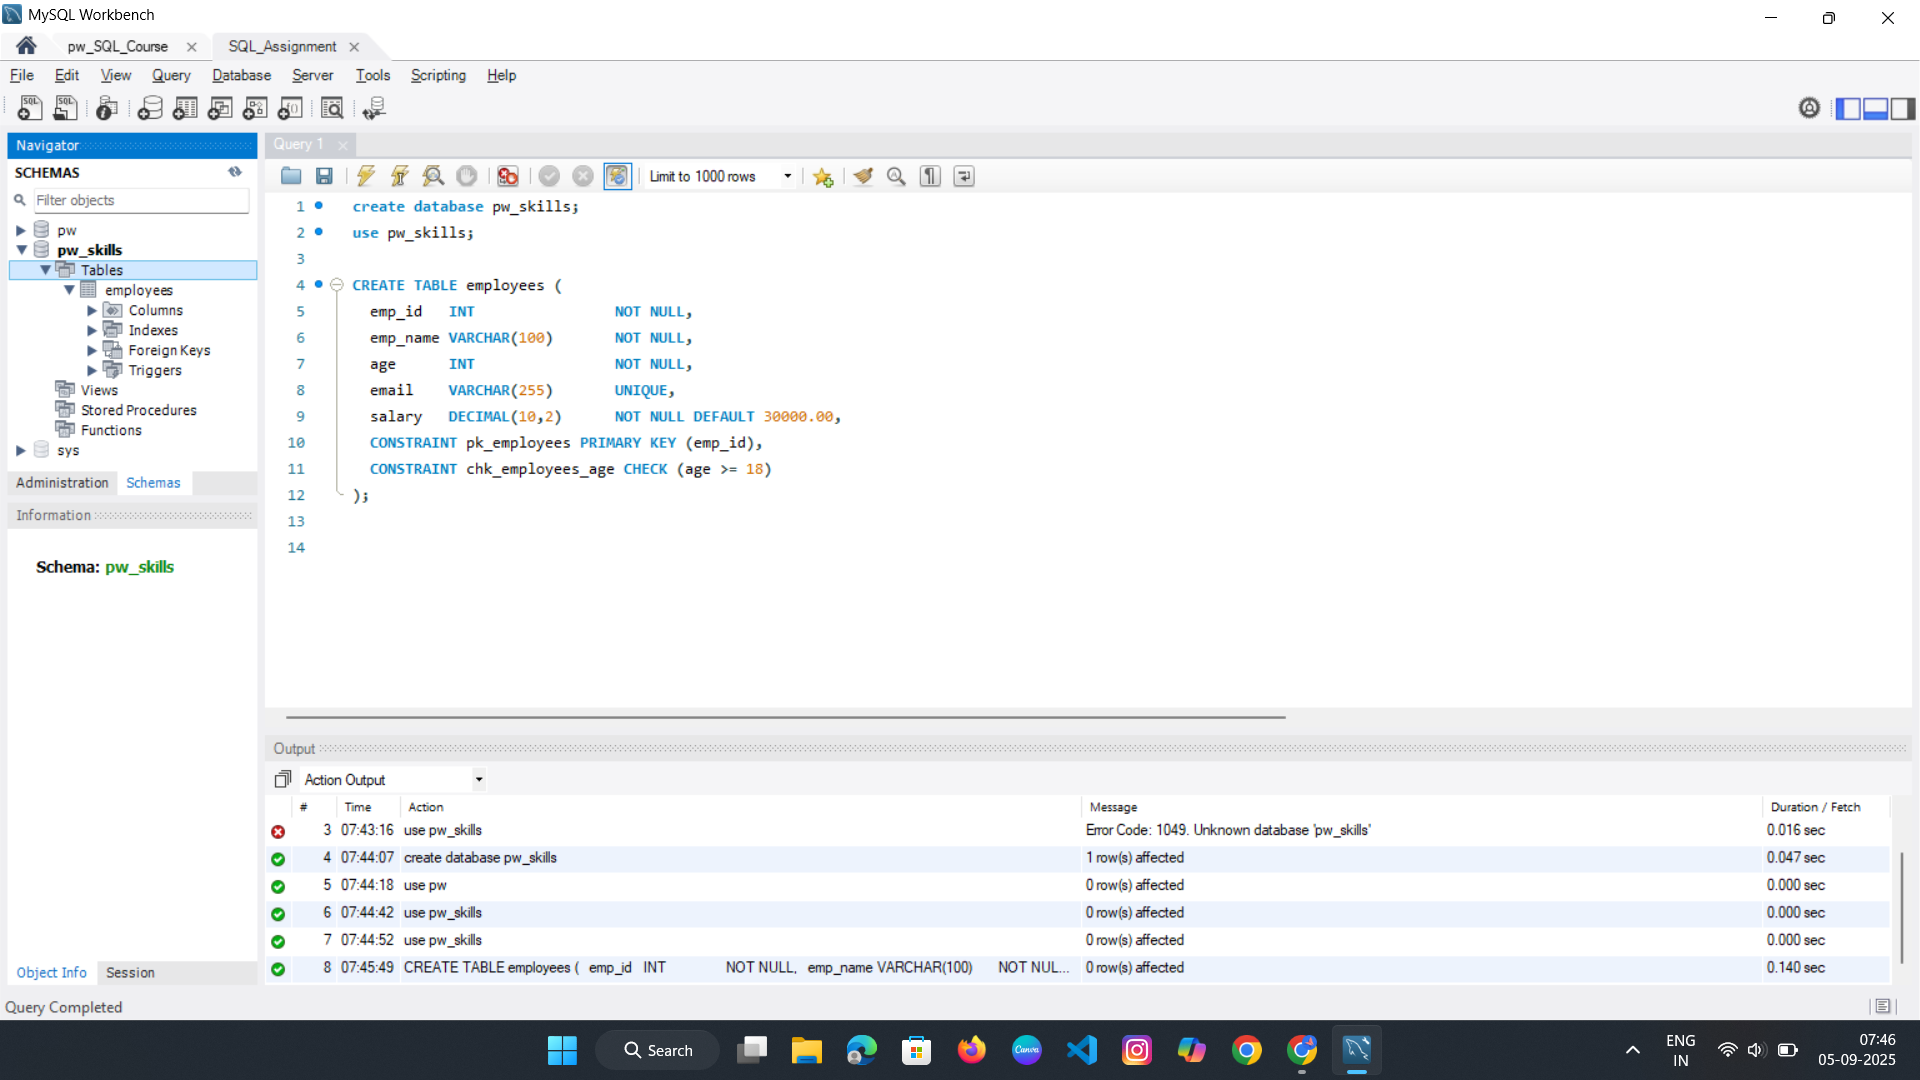

2. Explain the purpose of constraints and how they help maintain data integrity in a database. Provide examples of common types of constraints.

Purpose of constraints (with examples)

Why constraints? They enforce rules at the database level so bad data can’t get in—protecting integrity regardless of the app code.

Common types

PRIMARY KEY: uniquely identifies each row.

PRIMARY KEY (emp_id)

FOREIGN KEY: enforces valid references between tables.

FOREIGN KEY (dept_id) REFERENCES departments(dept_id)

UNIQUE: no duplicates allowed.

UNIQUE (email)

NOT NULL: value must be provided.

emp_name VARCHAR(100) NOT NULL

CHECK: boolean rule per row.

CHECK (age >= 18)

DEFAULT: fills in a value when omitted.

salary DECIMAL(10,2) DEFAULT 30000.00

3.Why would you apply the NOT NULL constraint to a column? Can a primary key contain NULL values? Justify your answer.

- NOT NULL stops missing/unknown values for required columns (e.g., names, amounts).

- Primary keys cannot contain NULLs—by definition, a Primary Key must uniquely identify every row, and NULL means “unknown,” which breaks identity and indexing semantics.

4. Explain the steps and SQL commands used to add or remove constraints on an existing table. Provide an example for both adding and removing a constraint.

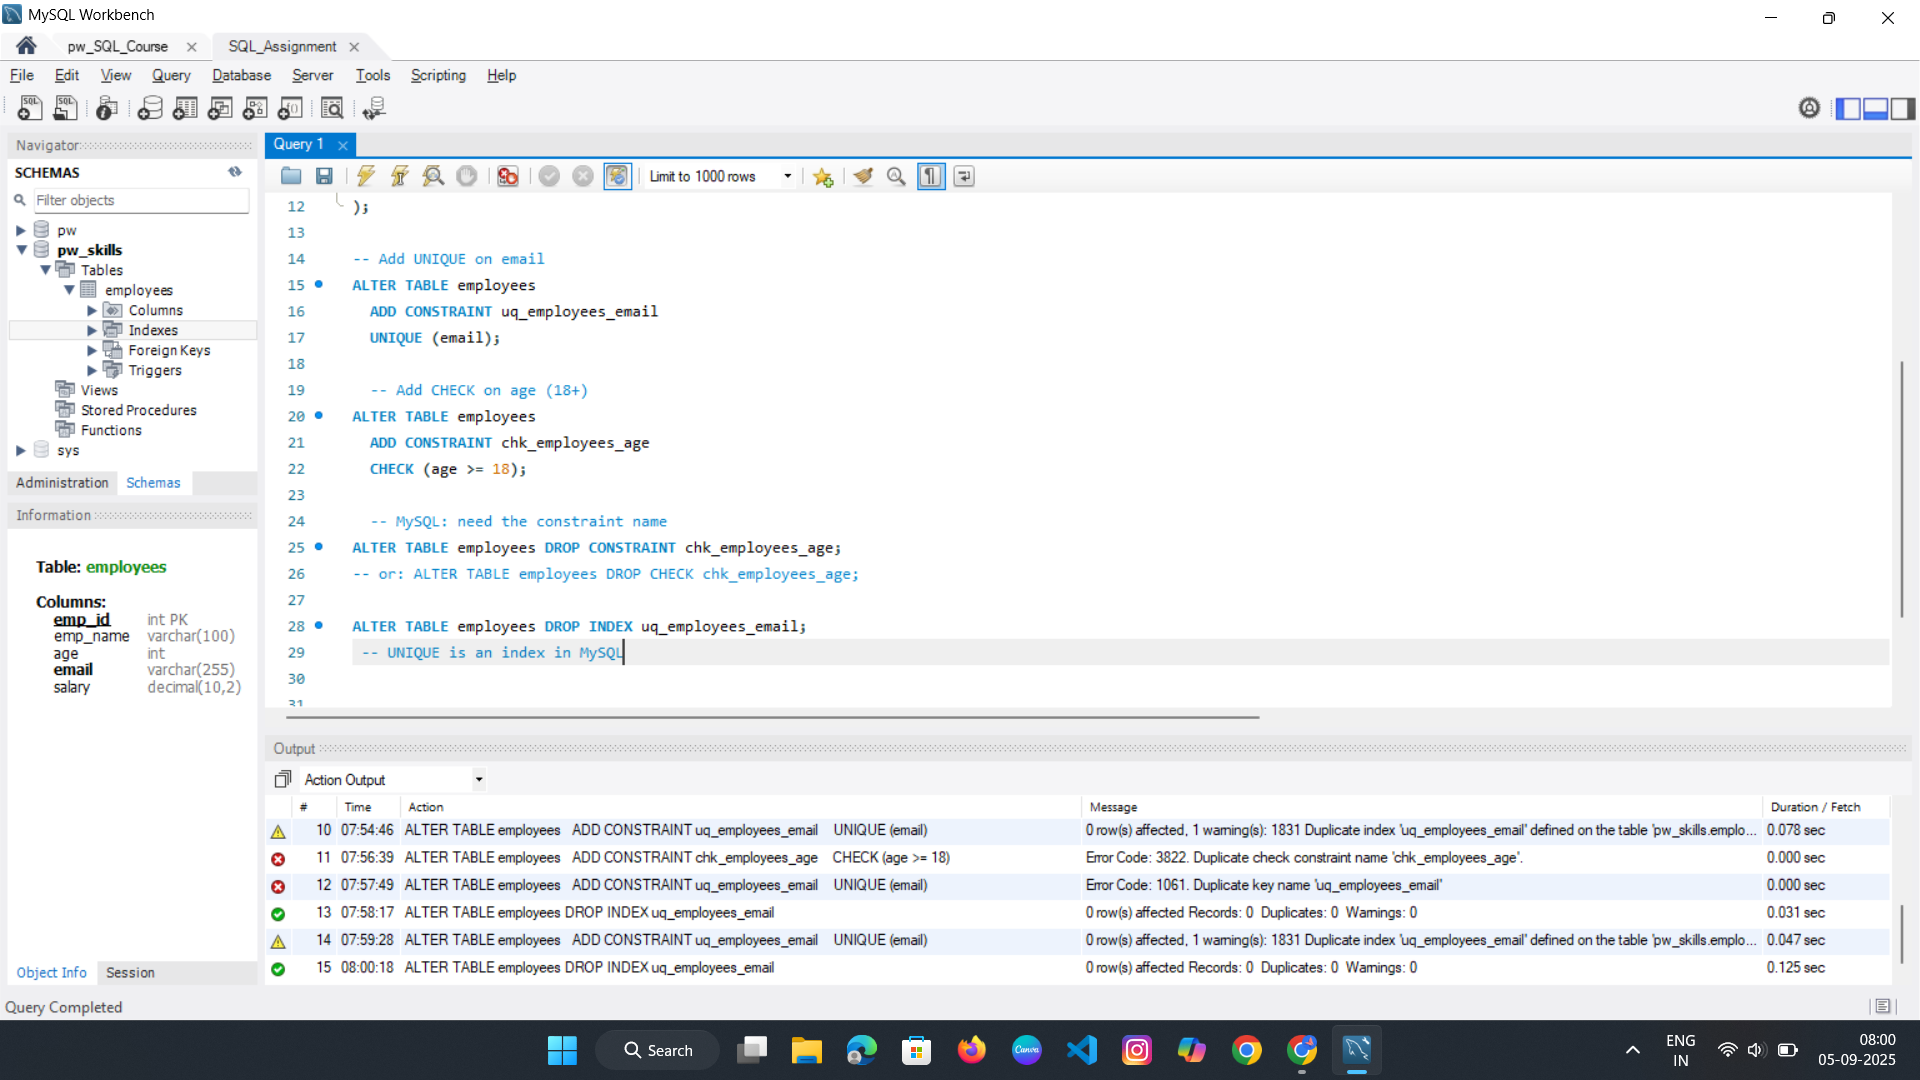

5. Explain the consequences of attempting to insert, update, or delete data in a way that violates constraints. Provide an example of an error message that might occur when violating a constraint.

The statement fails, no row change is committed, and you get an error. Examples:

Insert age < 18 ⇒ fails CHECK.

Duplicate email ⇒ fails UNIQUE.

NULL in emp_name ⇒ fails NOT NULL.

Invalid foreign key ⇒ fails FOREIGN KEY.

In [ ]:
#Example message (MySQL, UNIQUE)

ERROR 1062 (23000): Duplicate entry 'a@b.com' for key 'employees.uq_employees_email'


6. You created a products table without constraints as follows:

CREATE TABLE products (

    product_id INT,

    product_name VARCHAR(50),

    price DECIMAL(10, 2));

Now, you realise that?

: The product_id should be a primary key

: The price should have a default value of 50.00

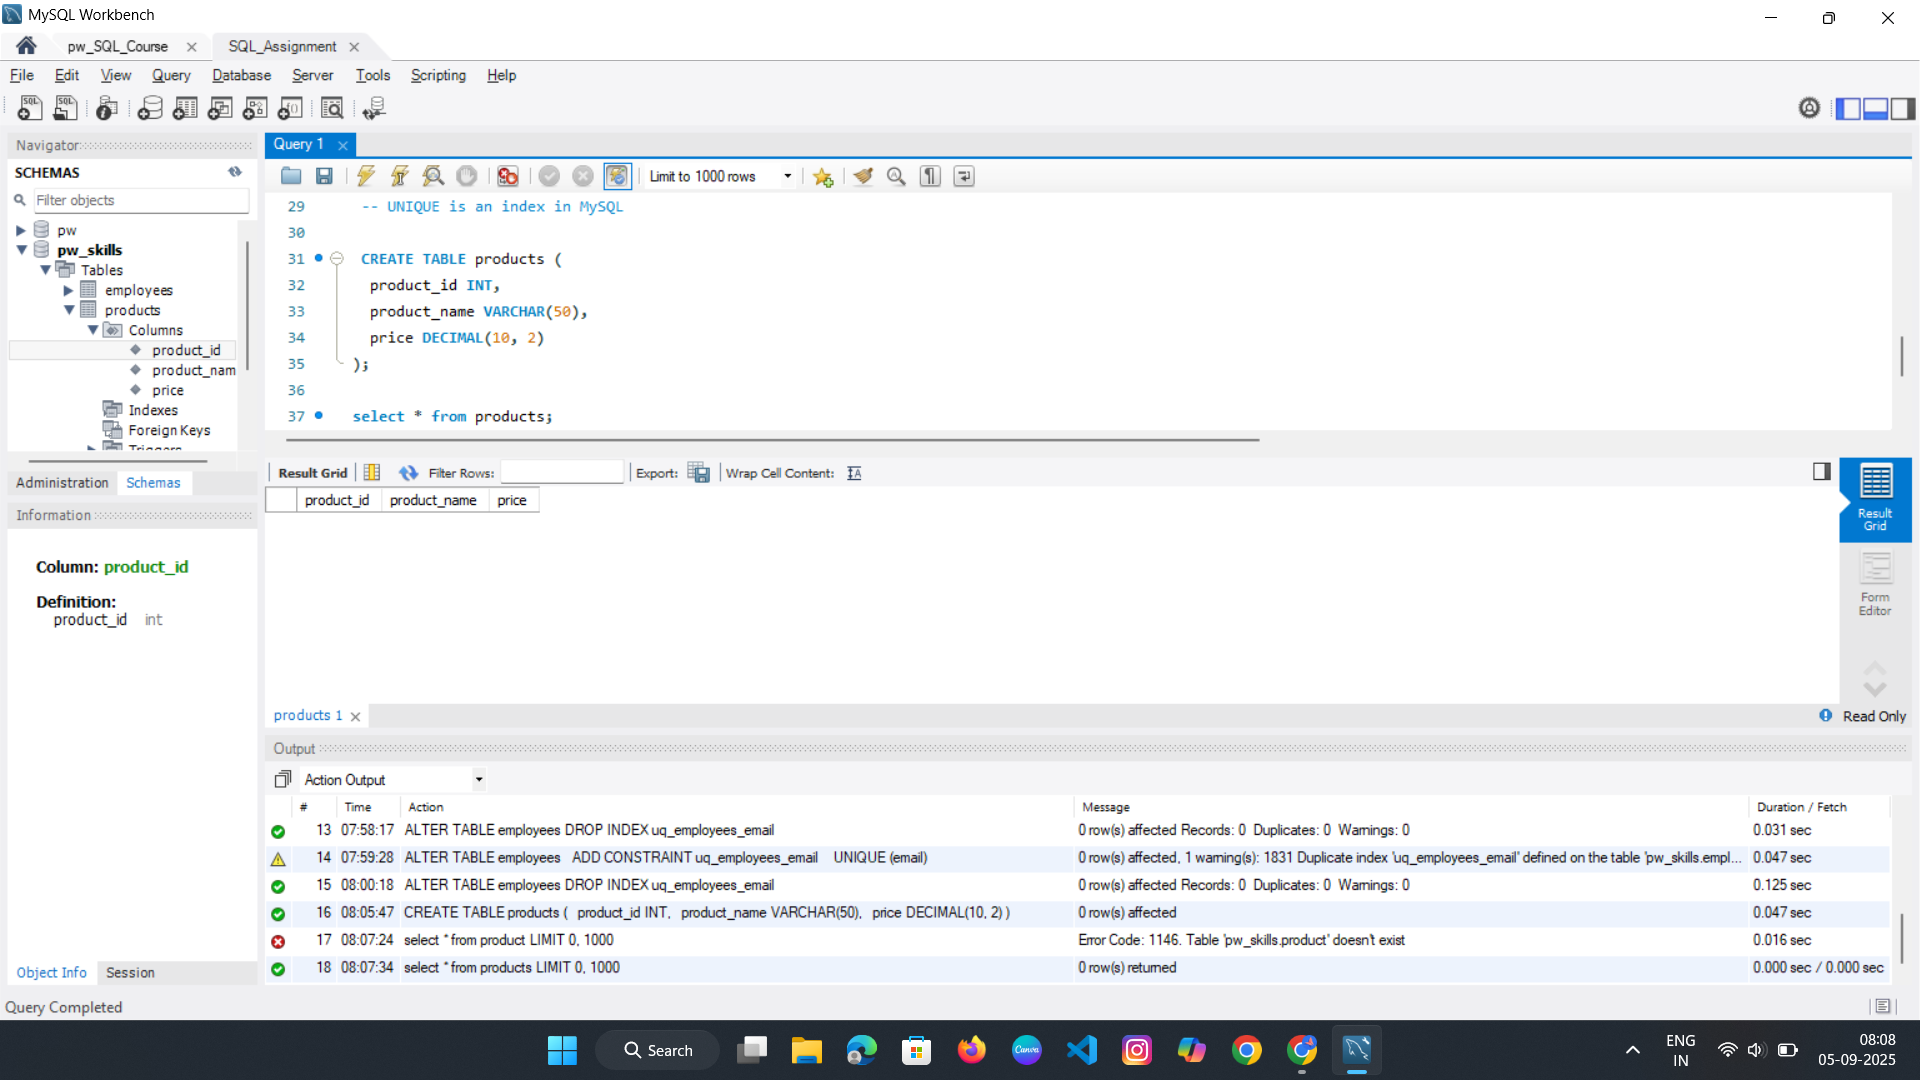

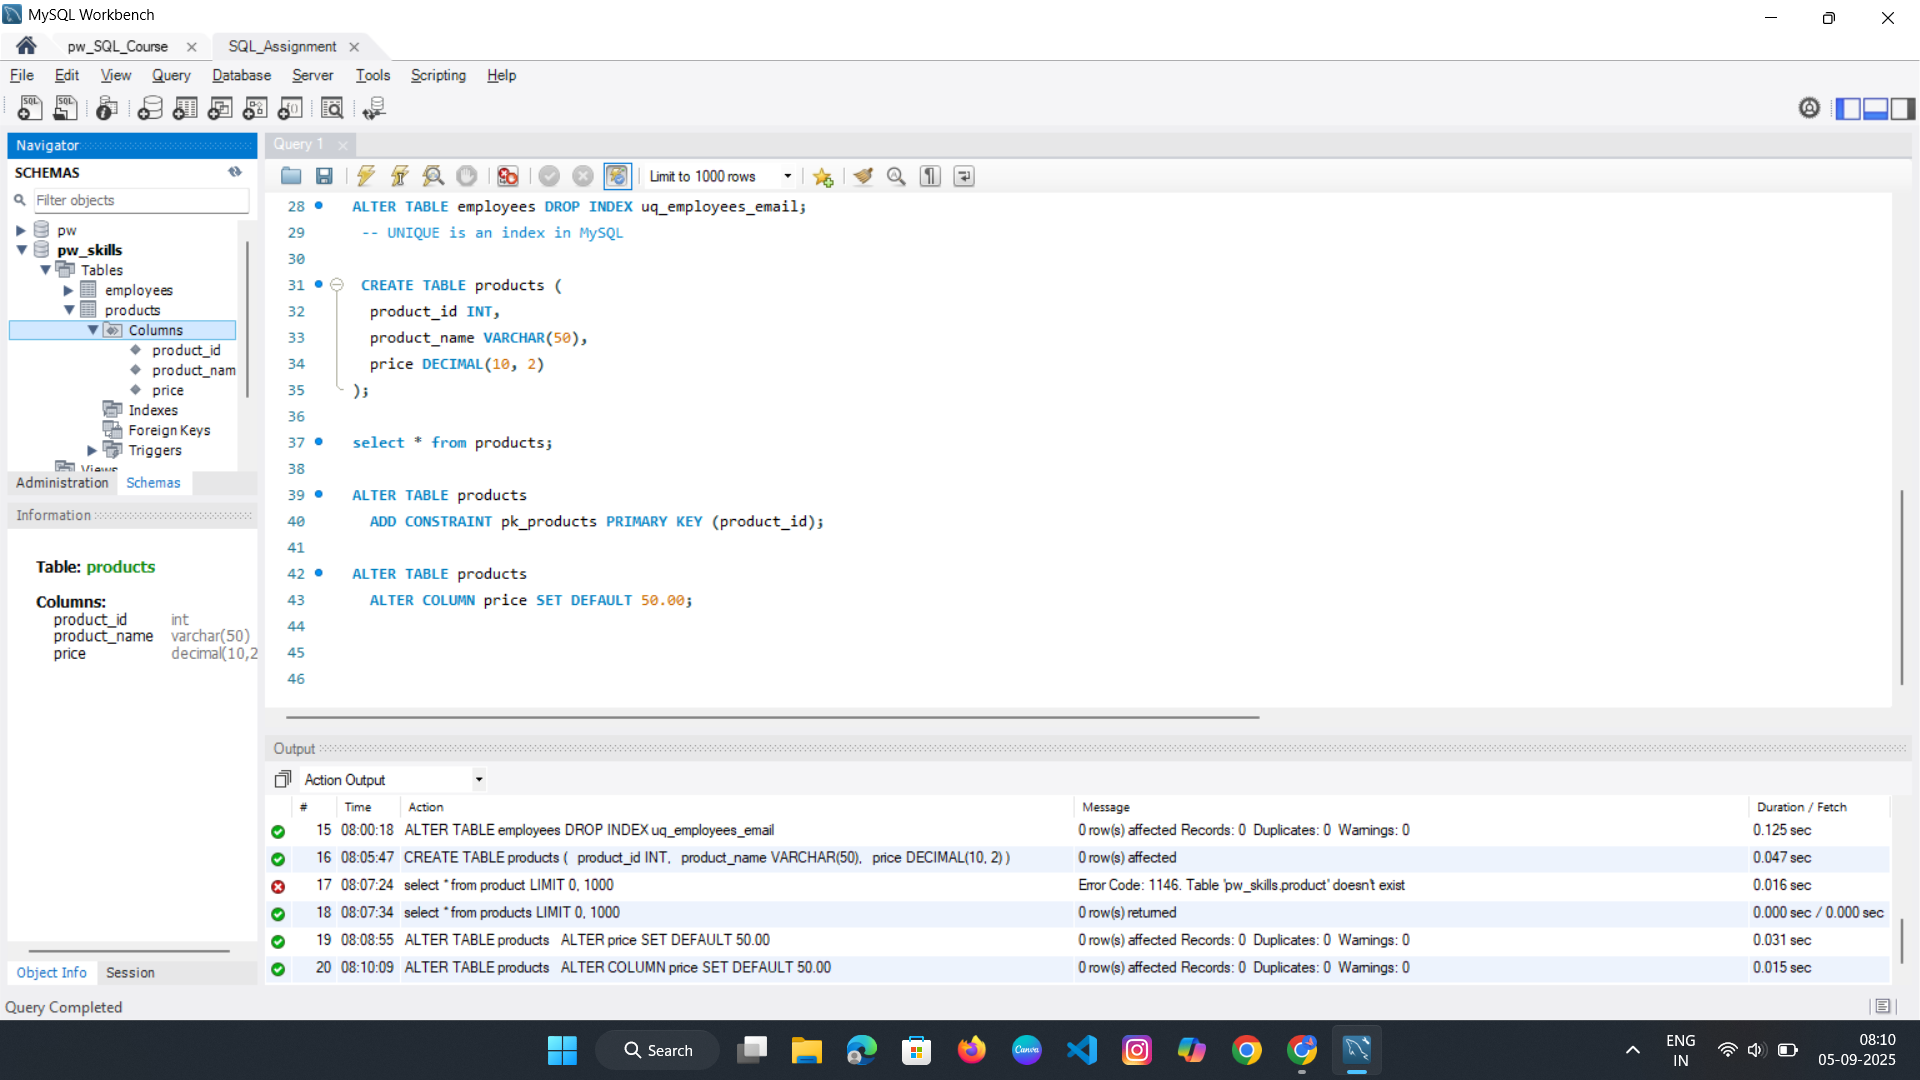

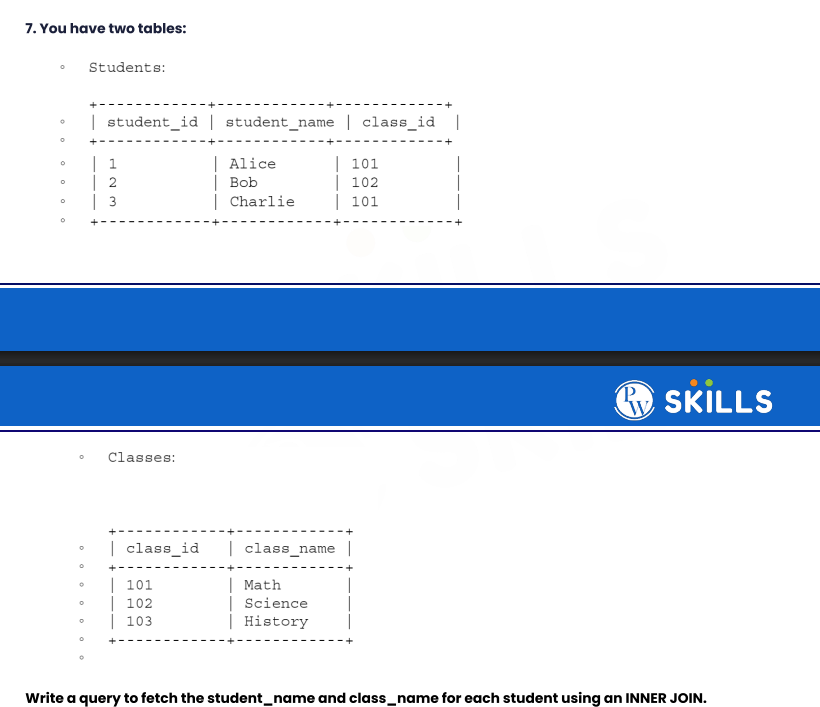

In [ ]:
#SQL Query
SELECT s.student_name, c.class_name
FROM Students s
INNER JOIN Classes c
ON s.class_id = c.class_id;

INNER JOIN matches rows from Students and Classes where class_id is the same in both tables.

Only students with a valid class match will appear.

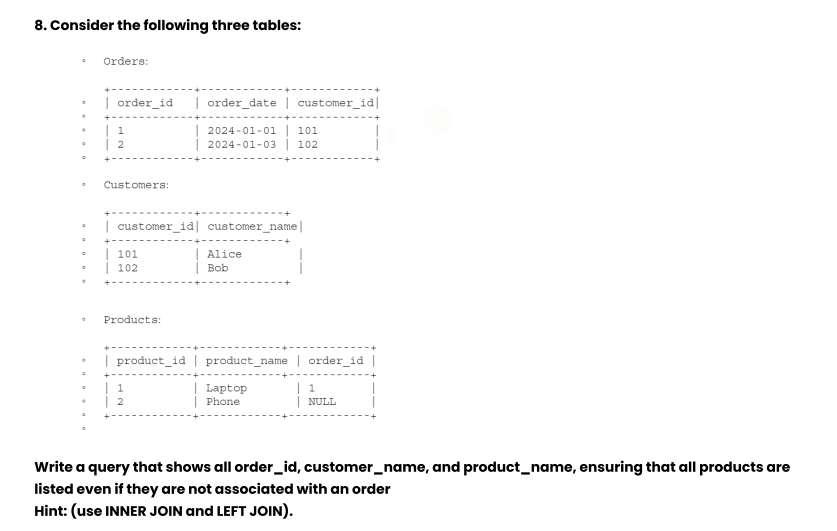

#Assumed tables:
orders(order_id, customer_id, order_date)

customers(customer_id, customer_name)

order_items(order_id, product_id, quantity)

products(product_id, product_name)

SELECT

  o.order_id,
  
  c.customer_name,

  p.product_name

FROM products p

LEFT JOIN order_items oi ON oi.product_id = p.product_id

LEFT JOIN orders o       ON o.order_id   = oi.order_id

LEFT JOIN customers c    ON c.customer_id= o.customer_id

ORDER BY p.product_name, o.order_id;


**LEFT JOIN from products ensures all products appear, even if not in any order.**

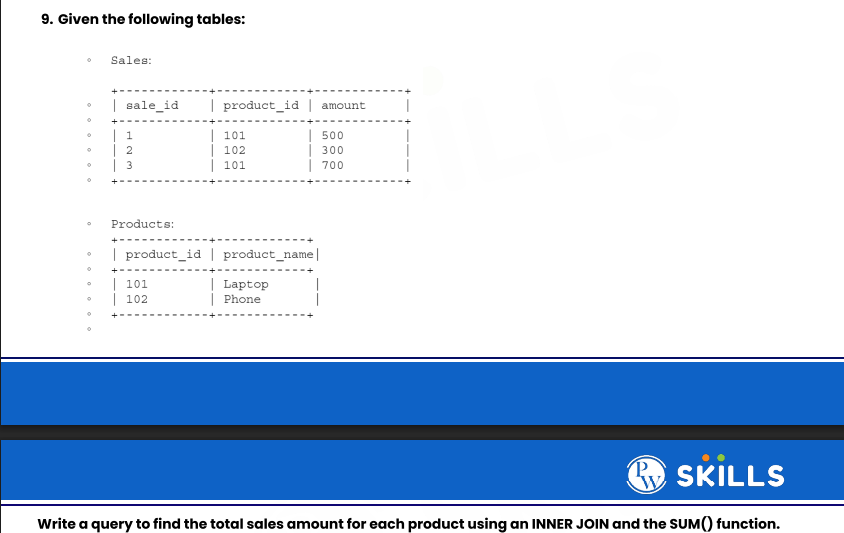

In [ ]:
SELECT
  p.product_id,
  p.product_name,
  SUM(oi.quantity * oi.unit_price) AS total_sales_amount
FROM order_items oi
JOIN products p ON p.product_id = oi.product_id
GROUP BY p.product_id, p.product_name
ORDER BY total_sales_amount DESC;

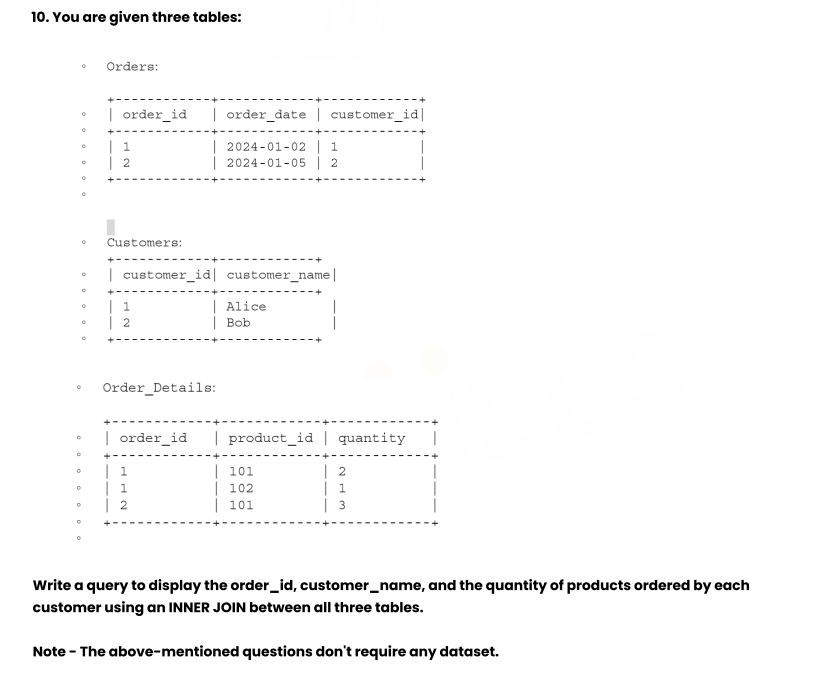

In [ ]:
SELECT
  o.order_id,
  c.customer_name,
  SUM(oi.quantity) AS total_quantity
FROM orders o
JOIN customers c  ON c.customer_id = o.customer_id
JOIN order_items oi ON oi.order_id = o.order_id
GROUP BY o.order_id, c.customer_name
ORDER BY o.order_id;


# **SQL Commands**

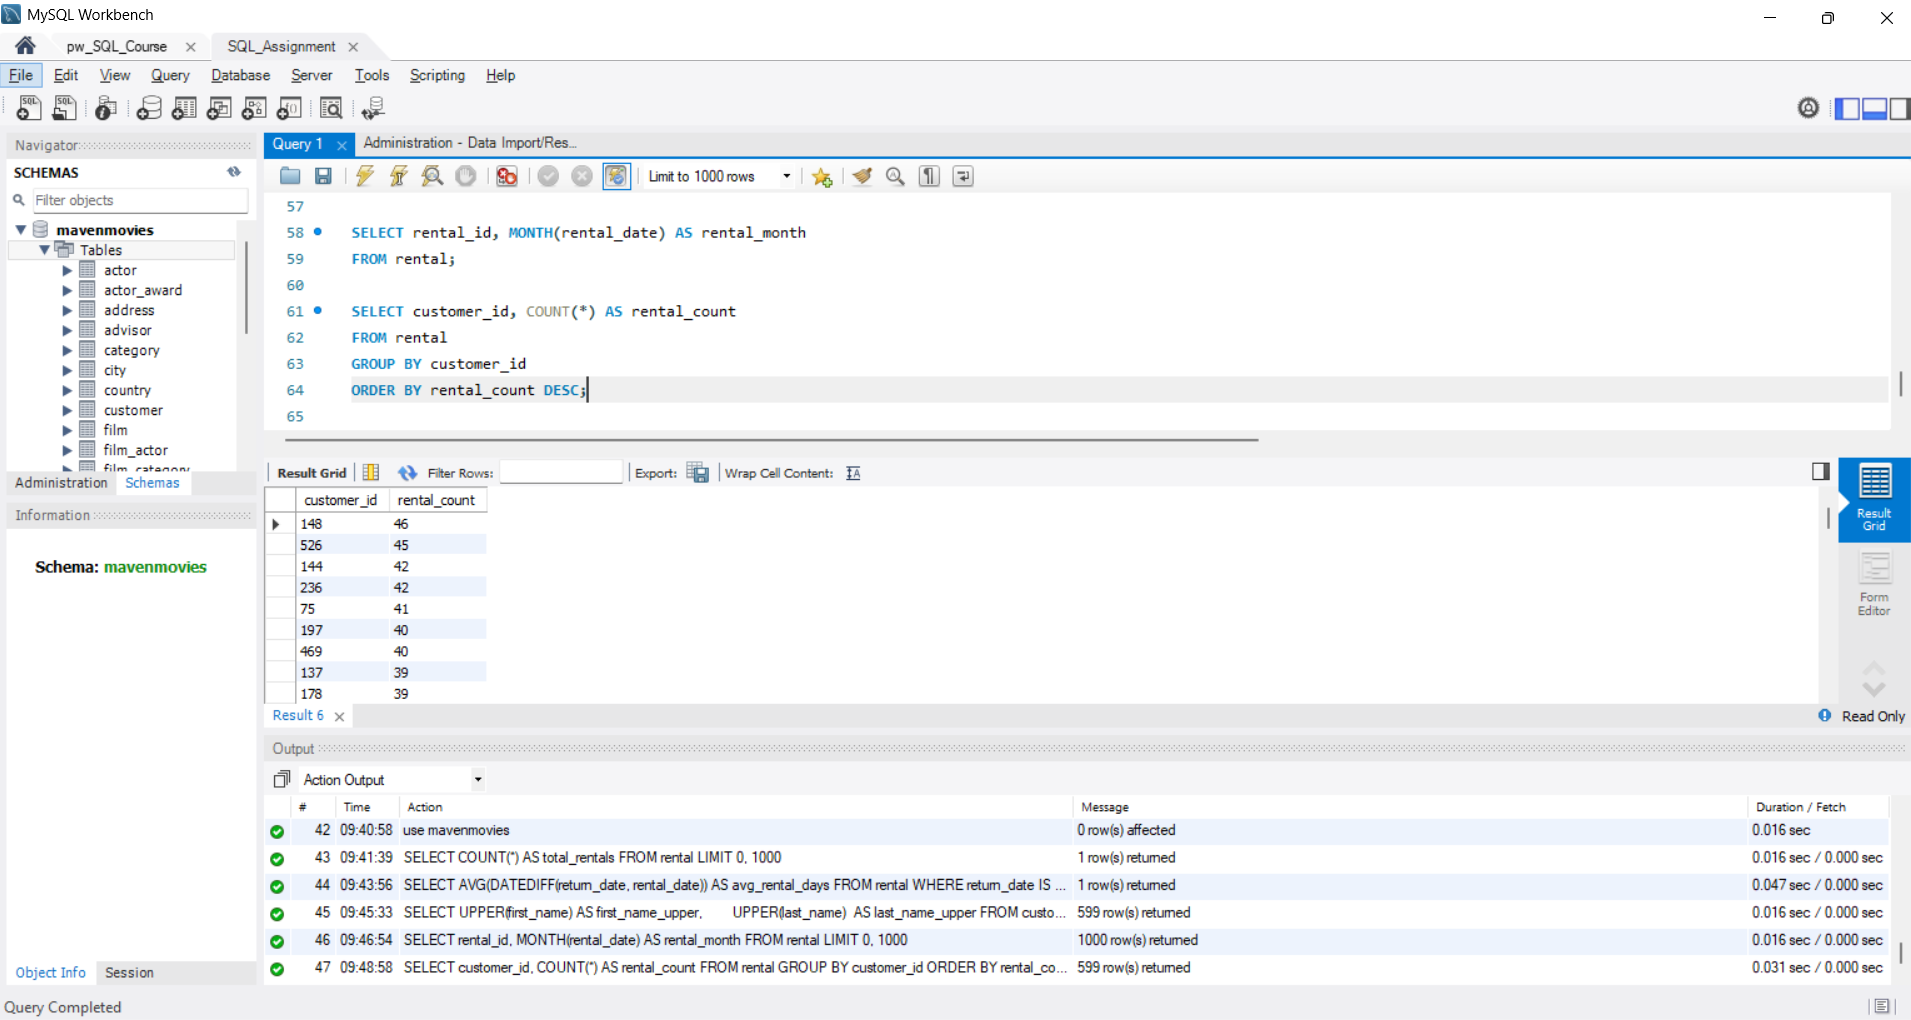

1-Identify the primary keys and foreign keys in maven movies db. Discuss the differences

-- MySQL quick inspect

SHOW KEYS FROM film;

SHOW CREATE TABLE rental;

-- In general: PRIMARY KEY columns (e.g., film.film_id)

-- FOREIGN KEY examples: rental.customer_id → customer.customer_id

2- List all details of actors

SELECT * FROM actor;


3 -List all customer information from DB.

SELECT * FROM customer;


4 -List different countries.

SELECT DISTINCT country FROM country ORDER BY country;


5 -Display all active customers.

SELECT * FROM customer WHERE active = 1;


6 -List of all rental IDs for customer with ID 1.

SELECT rental_id FROM rental WHERE customer_id = 1 ORDER BY rental_id;


7 - Display all the films whose rental duration is greater than 5 .

SELECT * FROM film WHERE rental_duration > 5;


8 - List the total number of films whose replacement cost is greater than $15 and less than $20

SELECT COUNT(*) AS film_count

FROM film

WHERE replacement_cost > 15 AND replacement_cost < 20;


9 - Display the count of unique first names of actors.

SELECT COUNT(DISTINCT first_name) AS unique_first_names

FROM actor;


10- Display the first 10 records from the customer table .

SELECT * FROM customer ORDER BY customer_id LIMIT 10;


11 - Display the first 3 records from the customer table whose first name starts with ‘b’.

SELECT *

FROM customer

WHERE first_name LIKE 'b%'

ORDER BY customer_id

LIMIT 3;


12 -Display the names of the first 5 movies which are rated as ‘G’.

SELECT title

FROM film

WHERE rating = 'G'

ORDER BY title

LIMIT 5;


13-Find all customers whose first name starts with "a".


SELECT * FROM customer WHERE first_name LIKE 'a%';


14- Find all customers whose first name ends with "a".

SELECT * FROM customer WHERE first_name LIKE '%a';


15- Display the list of first 4 cities which start and end with ‘a’ .

SELECT city

FROM city

WHERE city LIKE 'a%a'

ORDER BY city

LIMIT 4;


16- Find all customers whose first name have "NI" in any position.

SELECT * FROM customer WHERE first_name LIKE '%NI%';


17- Find all customers whose first name have "r" in the second position .

SELECT * FROM customer WHERE first_name LIKE '_r%';


18 - Find all customers whose first name starts with "a" and are at least 5 characters in length.

SELECT *

FROM customer

WHERE first_name LIKE 'a%' AND CHAR_LENGTH(first_name) >= 5;


19- Find all customers whose first name starts with "a" and ends with "o".

SELECT *

FROM customer

WHERE first_name LIKE 'a%o';


20 - Get the films with pg and pg-13 rating using IN operator.

SELECT * FROM film WHERE rating IN ('PG', 'PG-13');


21 - Get the films with length between 50 to 100 using between operator.

SELECT * FROM film WHERE length BETWEEN 50 AND 100;


22 - Get the top 50 actors using limit operator.

SELECT * FROM actor ORDER BY actor_id LIMIT 50;


23 - Get the distinct film ids from inventory table.

SELECT DISTINCT film_id FROM inventory ORDER BY film_id;


# **Functions**

**Basic Aggregate Functions:**

Question 1:

Retrieve the total number of rentals made in the Sakila database.

Hint: Use the COUNT() function.

SELECT COUNT(*) AS total_rentals FROM rental;


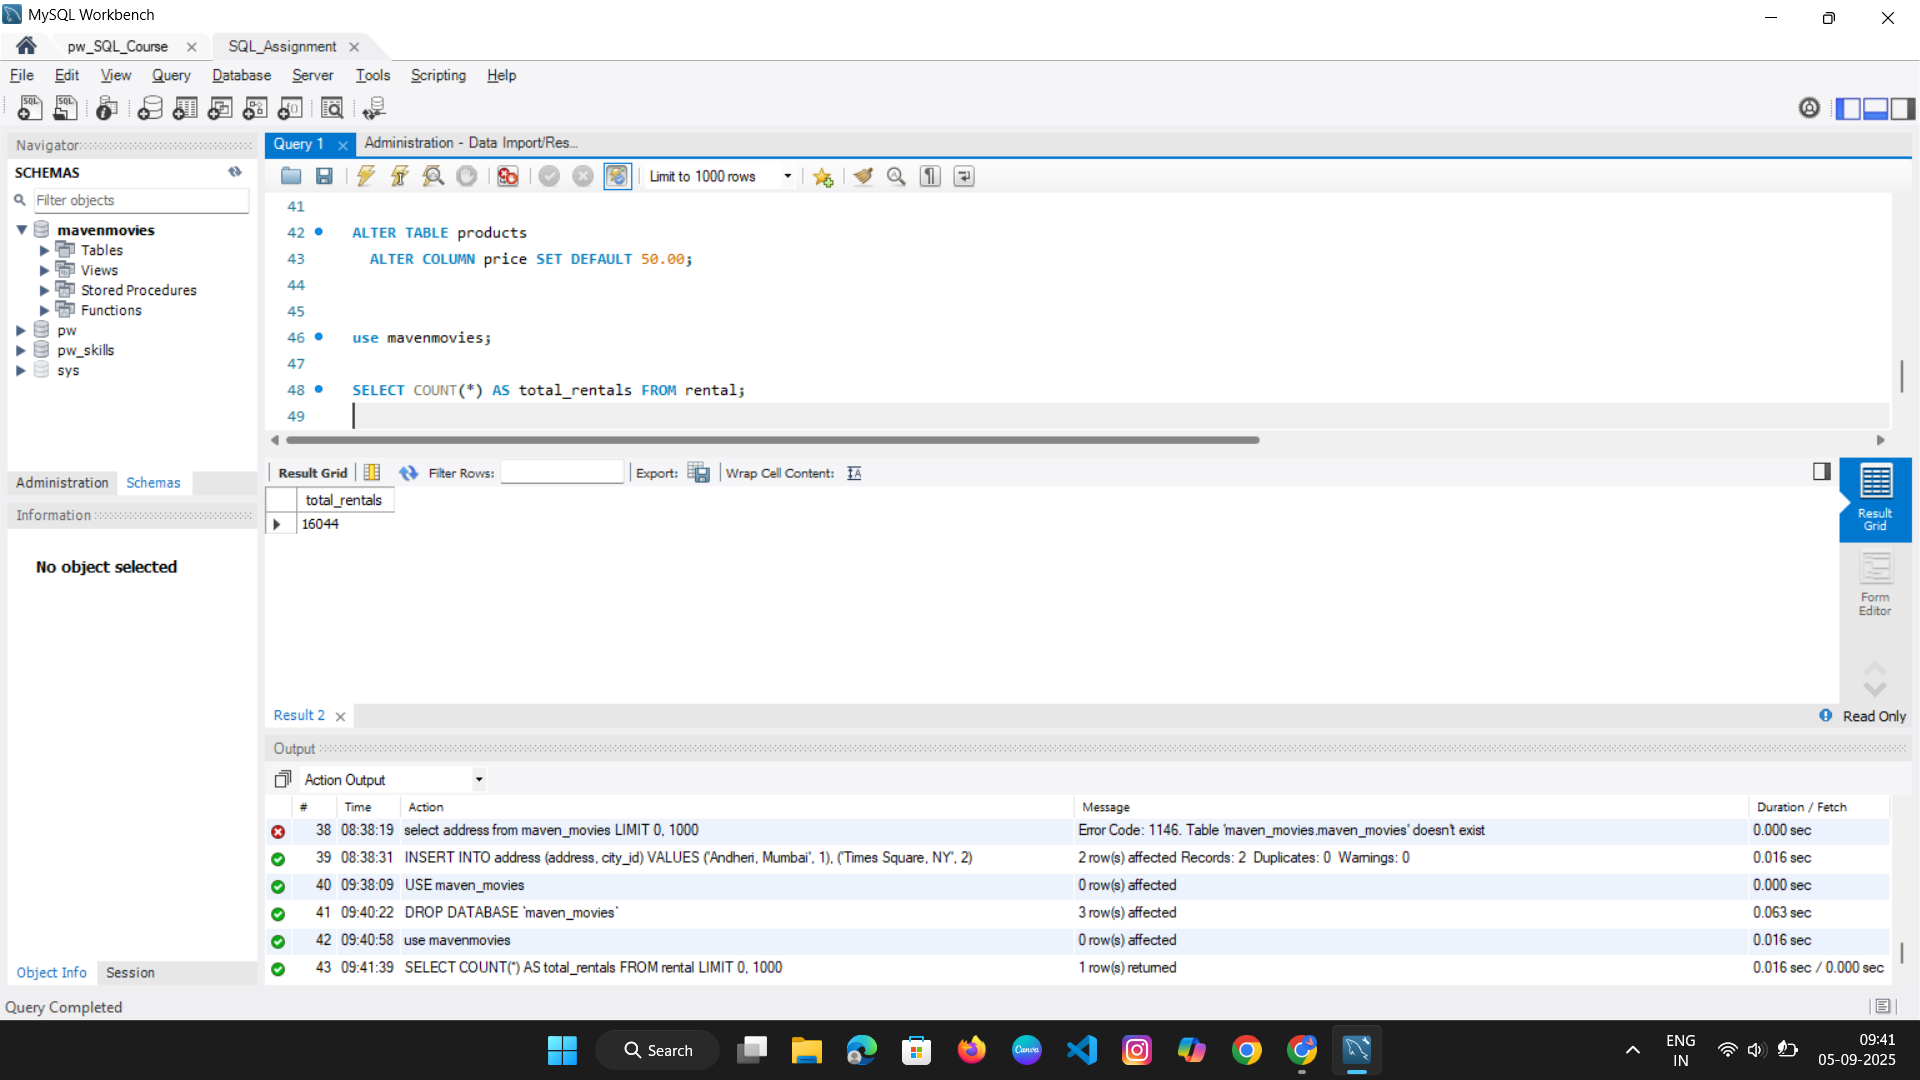

Question 2:

Find the average rental duration (in days) of movies rented from the Sakila database.

Hint: Utilize the AVG() function.

SELECT AVG(DATEDIFF(return_date, rental_date)) AS avg_rental_days

FROM rental

WHERE return_date IS NOT NULL;


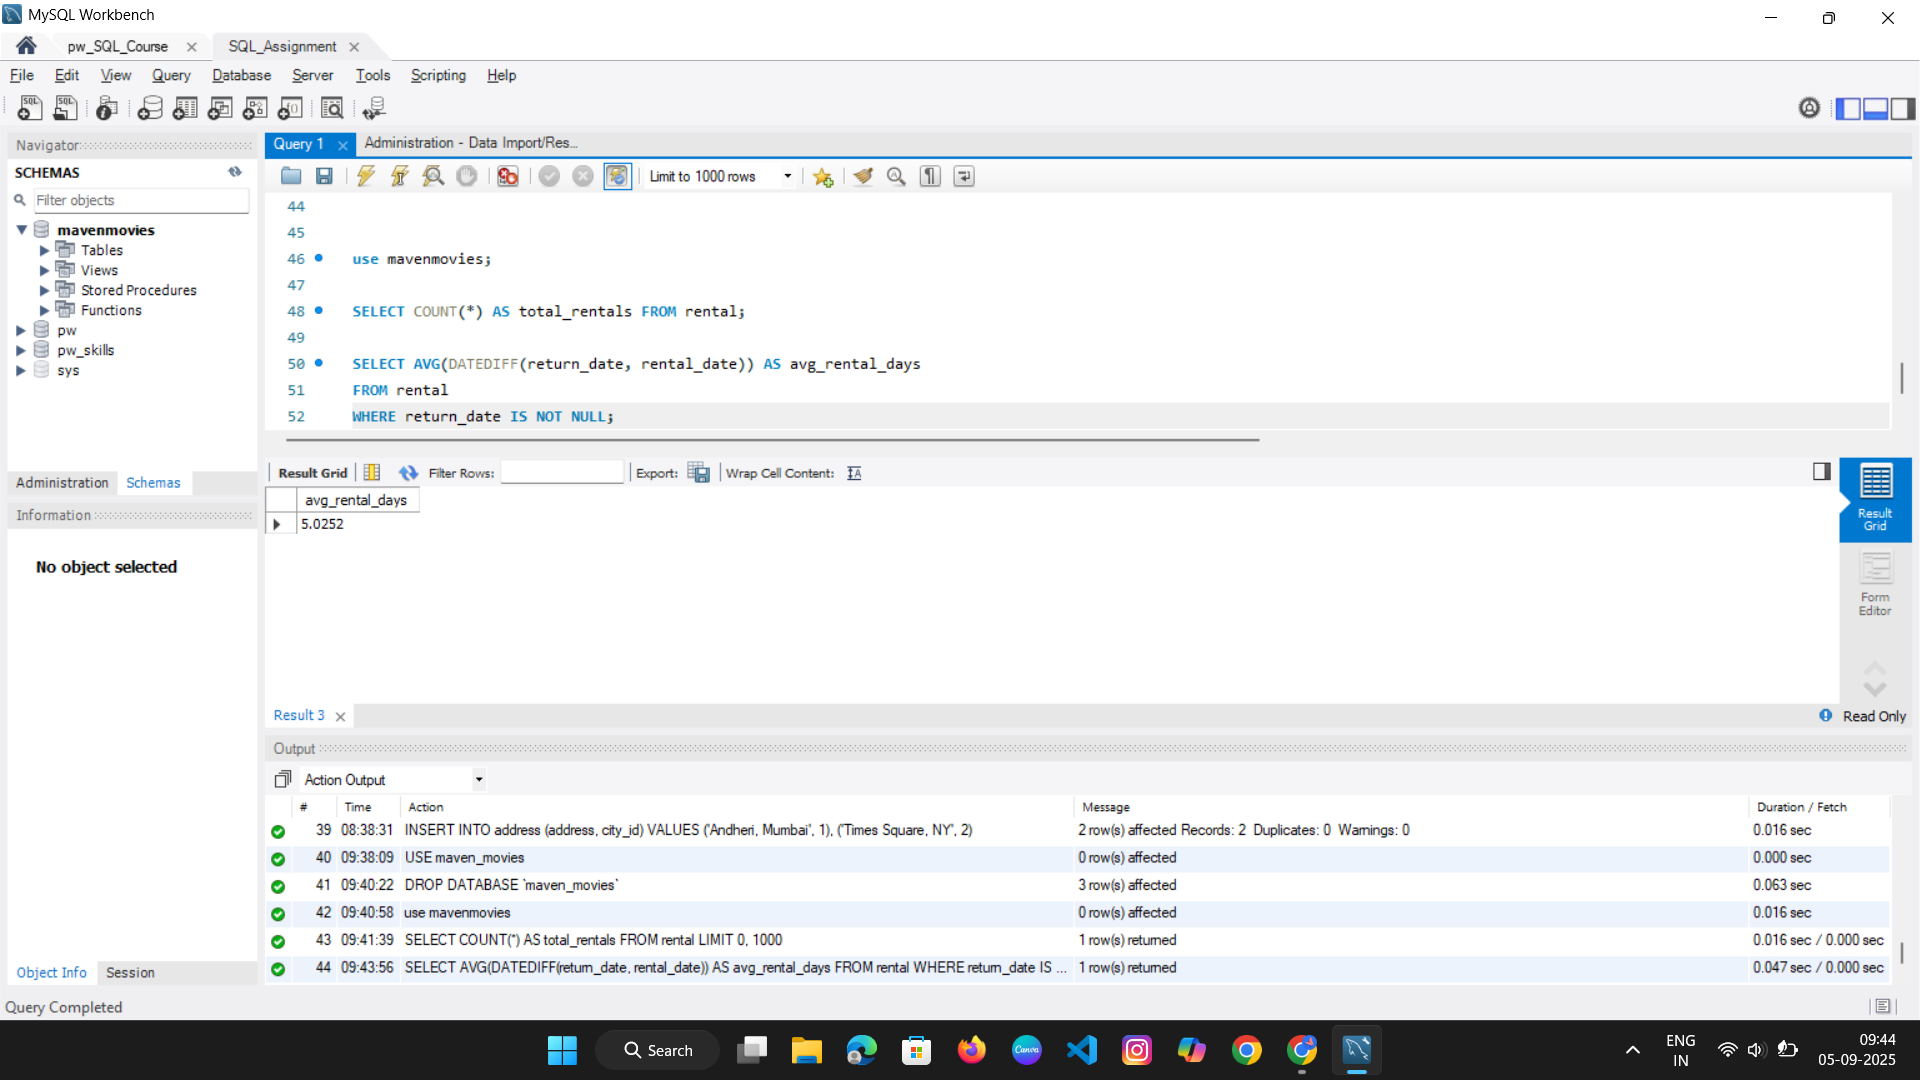

String Functions:

Question 3:

Display the first name and last name of customers in uppercase.

Hint: Use the UPPER () function.

SELECT

UPPER(first_name) AS first_name_upper,

UPPER(last_name)  AS last_name_upper

FROM customer;


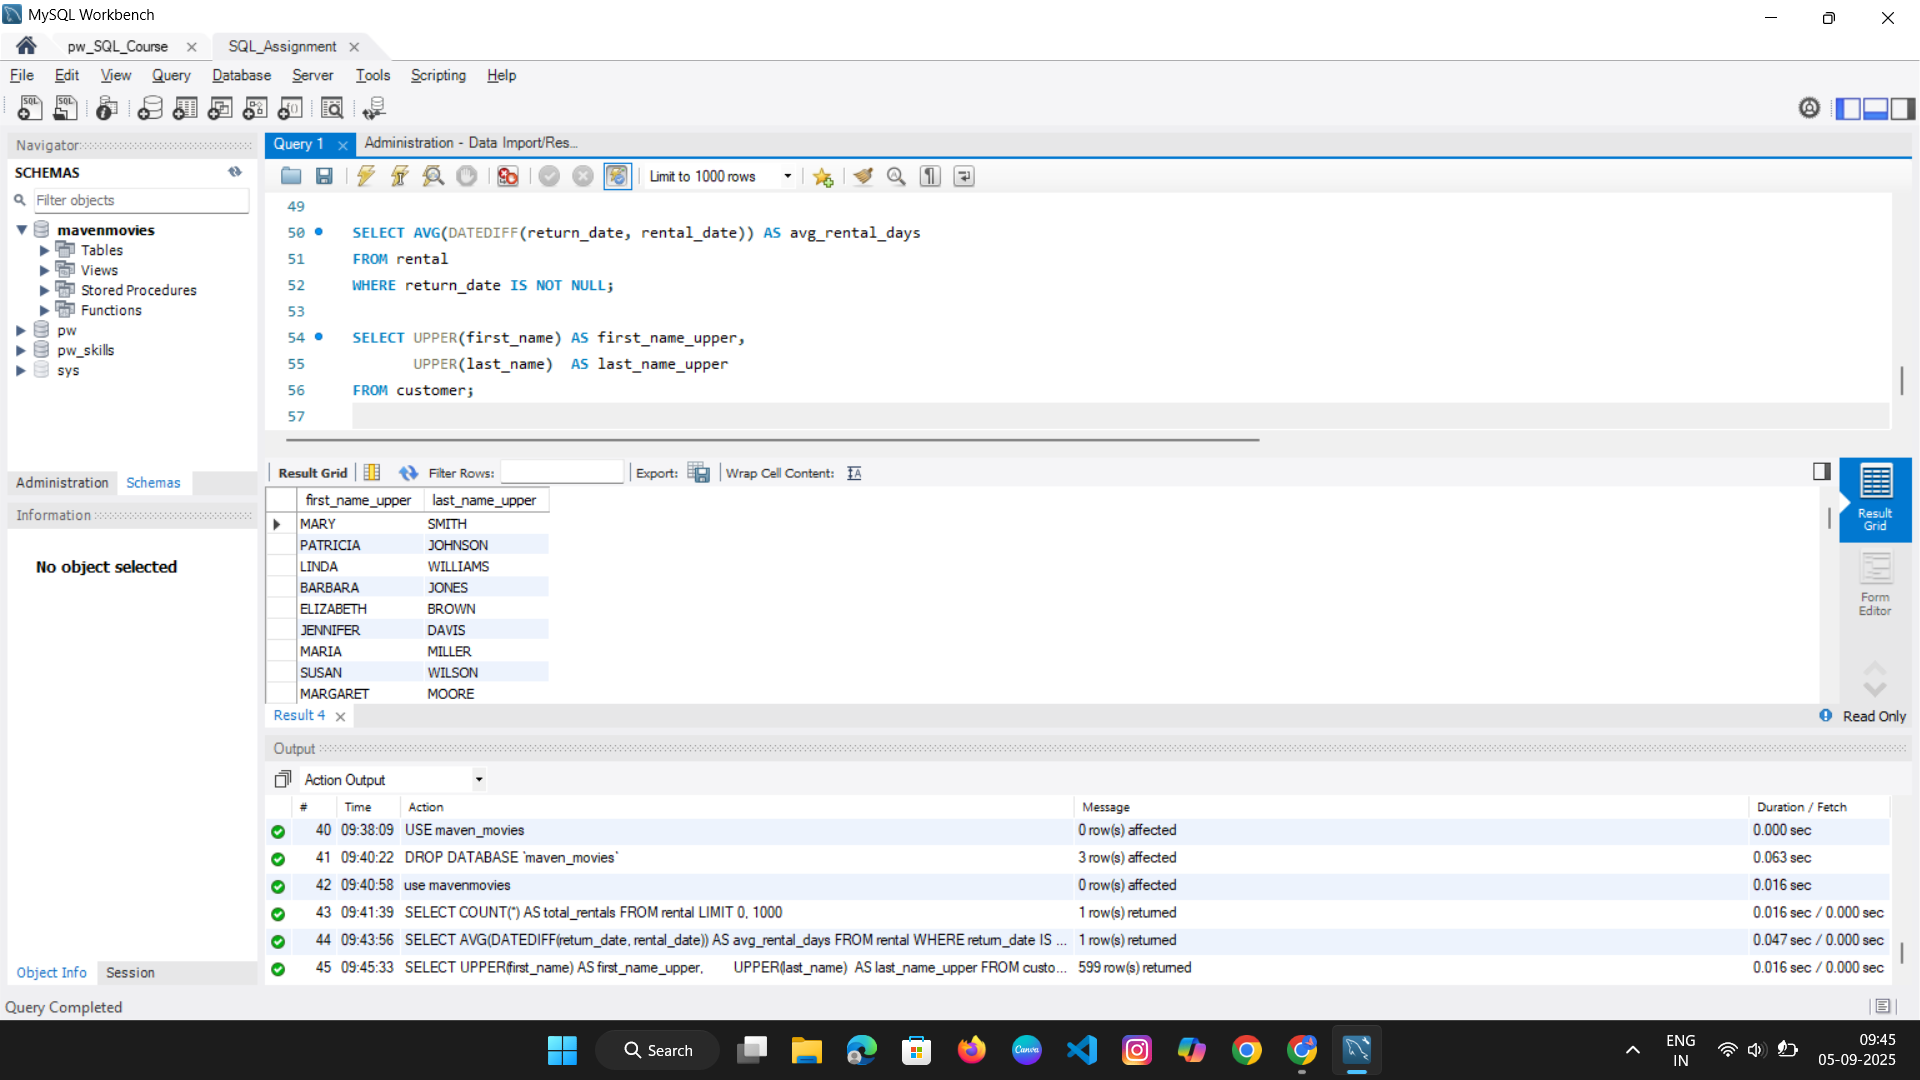

Question 4:

Extract the month from the rental date and display it alongside the rental ID.

Hint: Employ the MONTH() function.

SELECT rental_id, MONTH(rental_date) AS rental_month

FROM rental;


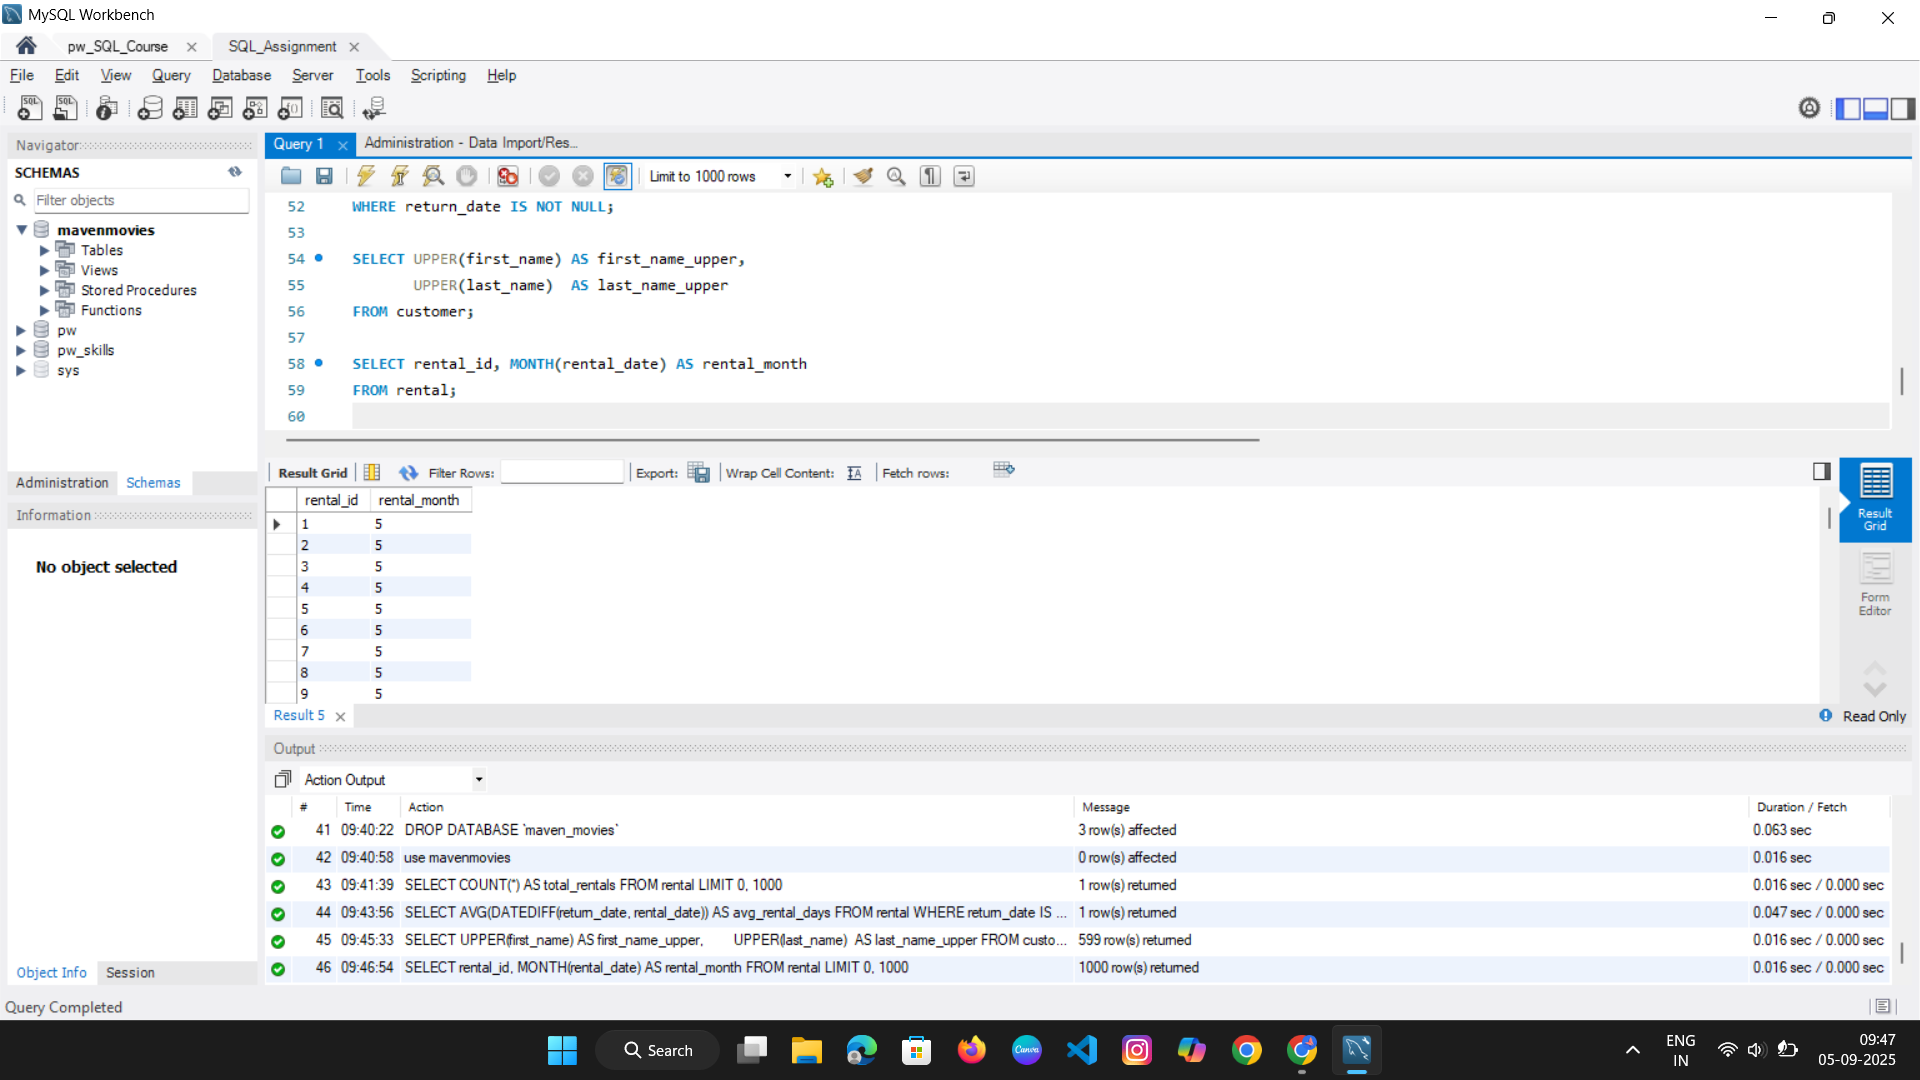

GROUP BY:


Question 5:

Retrieve the count of rentals for each customer (display customer ID and the count of rentals).

Hint: Use COUNT () in conjunction with GROUP BY.

SELECT customer_id, COUNT(*) AS rental_count

FROM rental

GROUP BY customer_id

ORDER BY rental_count DESC;


Question 6:

Find the total revenue generated by each store.

Hint: Combine SUM() and GROUP BY.

SELECT s.store_id, SUM(p.amount) AS total_revenue

FROM store s

JOIN staff st   ON st.store_id = s.store_id

JOIN payment p  ON p.staff_id  = st.staff_id

GROUP BY s.store_id

ORDER BY total_revenue DESC;


Question 7:

Determine the total number of rentals for each category of movies.

Hint: JOIN film_category, film, and rental tables, then use cOUNT () and GROUP BY.

SELECT c.name AS category,

       COUNT(*) AS rental_count

FROM category c

JOIN film_category fc ON fc.category_id = c.category_id

JOIN film f           ON f.film_id      = fc.film_id

JOIN inventory i      ON i.film_id      = f.film_id

JOIN rental r         ON r.inventory_id = i.inventory_id

GROUP BY c.name

ORDER BY rental_count DESC;


Question 8:

Find the average rental rate of movies in each language.

Hint: JOIN film and language tables, then use AVG () and GROUP BY.

SELECT l.name AS language_name,

       AVG(f.rental_rate) AS avg_rental_rate

FROM language l

JOIN film f ON f.language_id = l.language_id

GROUP BY l.name

ORDER BY avg_rental_rate DESC;


**Joins**

Questions 9 -

Display the title of the movie, customer s first name, and last name who rented it.

Hint: Use JOIN between the film, inventory, rental, and customer tables.


SELECT f.title, c.first_name, c.last_name

FROM film f

JOIN inventory i ON i.film_id = f.film_id

JOIN rental r    ON r.inventory_id = i.inventory_id

JOIN customer c  ON c.customer_id  = r.customer_id;


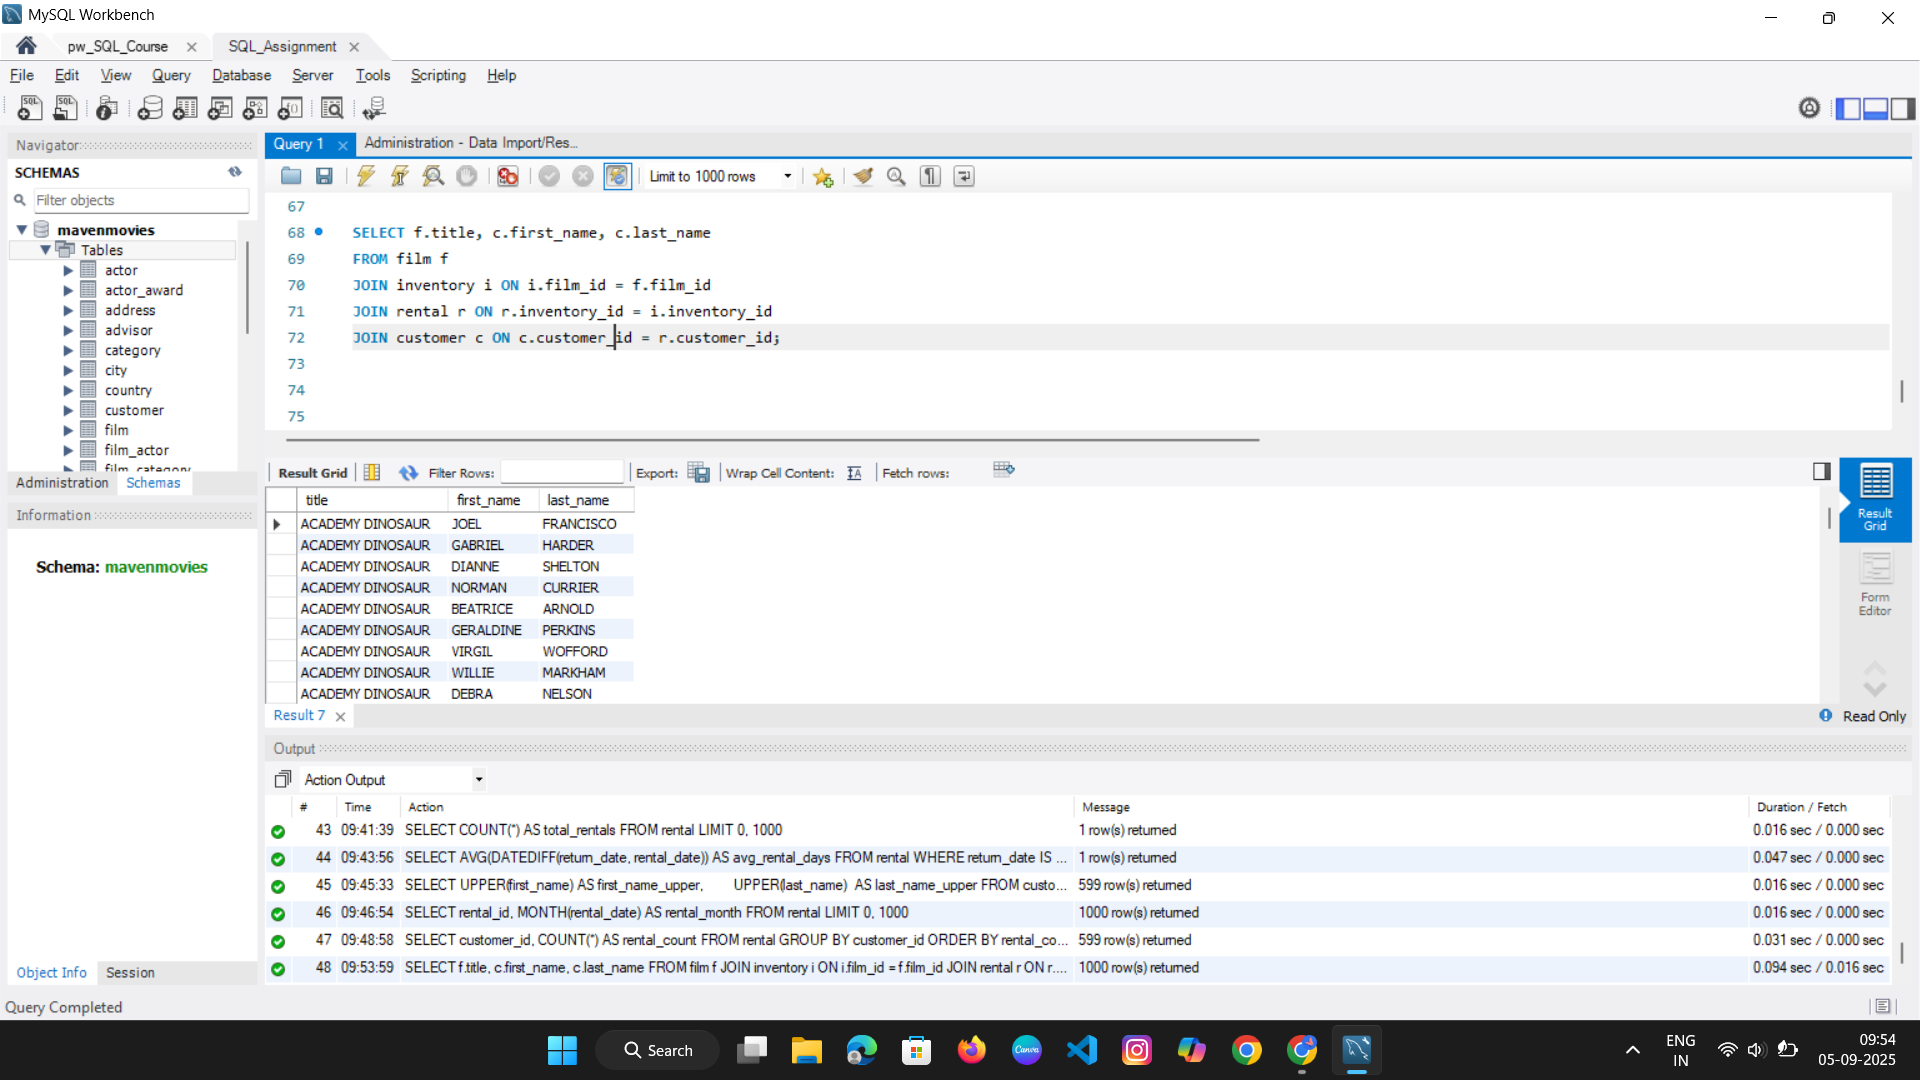

Question 10:

Retrieve the names of all actors who have appeared in the film "Gone with the Wind."

Hint: Use JOIN between the film actor, film, and actor tables.

SELECT a.first_name, a.last_name

FROM actor a

JOIN film_actor fa ON fa.actor_id = a.actor_id

JOIN film f        ON f.film_id   = fa.film_id

WHERE f.title = 'Gone with the Wind';


Question 11:

Retrieve the customer names along with the total amount they've spent on rentals.

Hint: JOIN customer, payment, and rental tables, then use SUM() and GROUP BY.

SELECT c.customer_id, c.first_name, c.last_name,

       SUM(p.amount) AS total_spent

FROM customer c

JOIN payment p ON p.customer_id = c.customer_id

GROUP BY c.customer_id, c.first_name, c.last_name

ORDER BY total_spent DESC;


Question 12:

List the titles of movies rented by each customer in a particular city (e.g., 'London').

Hint: JOIN customer, address, city, rental, inventory, and film tables, then use GROUP BY.

SELECT ci.city, c.customer_id, c.first_name, c.last_name,

       GROUP_CONCAT(DISTINCT f.title ORDER BY f.title SEPARATOR ', ') AS
       titles_rented

FROM customer c

JOIN address a   ON a.address_id = c.address_id

JOIN city ci     ON ci.city_id    = a.city_id

JOIN rental r    ON r.customer_id = c.customer_id

JOIN inventory i ON i.inventory_id= r.inventory_id

JOIN film f      ON f.film_id     = i.film_id

WHERE ci.city = 'London'

GROUP BY ci.city, c.customer_id, c.first_name, c.last_name

ORDER BY c.customer_id;


**Advanced Joins and GROUP BY:**

Question 13:

Display the top 5 rented movies along with the number of times they've been rented.

Hint: JOIN film, inventory, and rental tables, then use COUNT () and GROUP BY, and limit the results.

SELECT f.film_id, f.title, COUNT(*) AS times_rented

FROM film f

JOIN inventory i ON i.film_id = f.film_id

JOIN rental r    ON r.inventory_id = i.inventory_id

GROUP BY f.film_id, f.title

ORDER BY times_rented DESC

LIMIT 5;


Question 14:

Determine the customers who have rented movies from both stores (store ID 1 and store ID 2).

Hint: Use JOINS with rental, inventory, and customer tables and consider COUNT() and GROUP BY.

SELECT customer_id

FROM rental r

JOIN inventory i ON i.inventory_id = r.inventory_id

JOIN store s     ON s.store_id      = i.store_id

GROUP BY customer_id

HAVING SUM(s.store_id = 1) > 0
        
       AND SUM(s.store_id = 2) > 0;


# **Windows Function:**

1. Rank the customers based on the total amount they've spent on rentals.

In [ ]:
SELECT customer_id, first_name, last_name, total_spent,
       RANK() OVER (ORDER BY total_spent DESC) AS spend_rank
FROM (
  SELECT c.customer_id, c.first_name, c.last_name, SUM(p.amount) AS total_spent
  FROM customer c
  JOIN payment p ON p.customer_id = c.customer_id
  GROUP BY c.customer_id, c.first_name, c.last_name
) t;


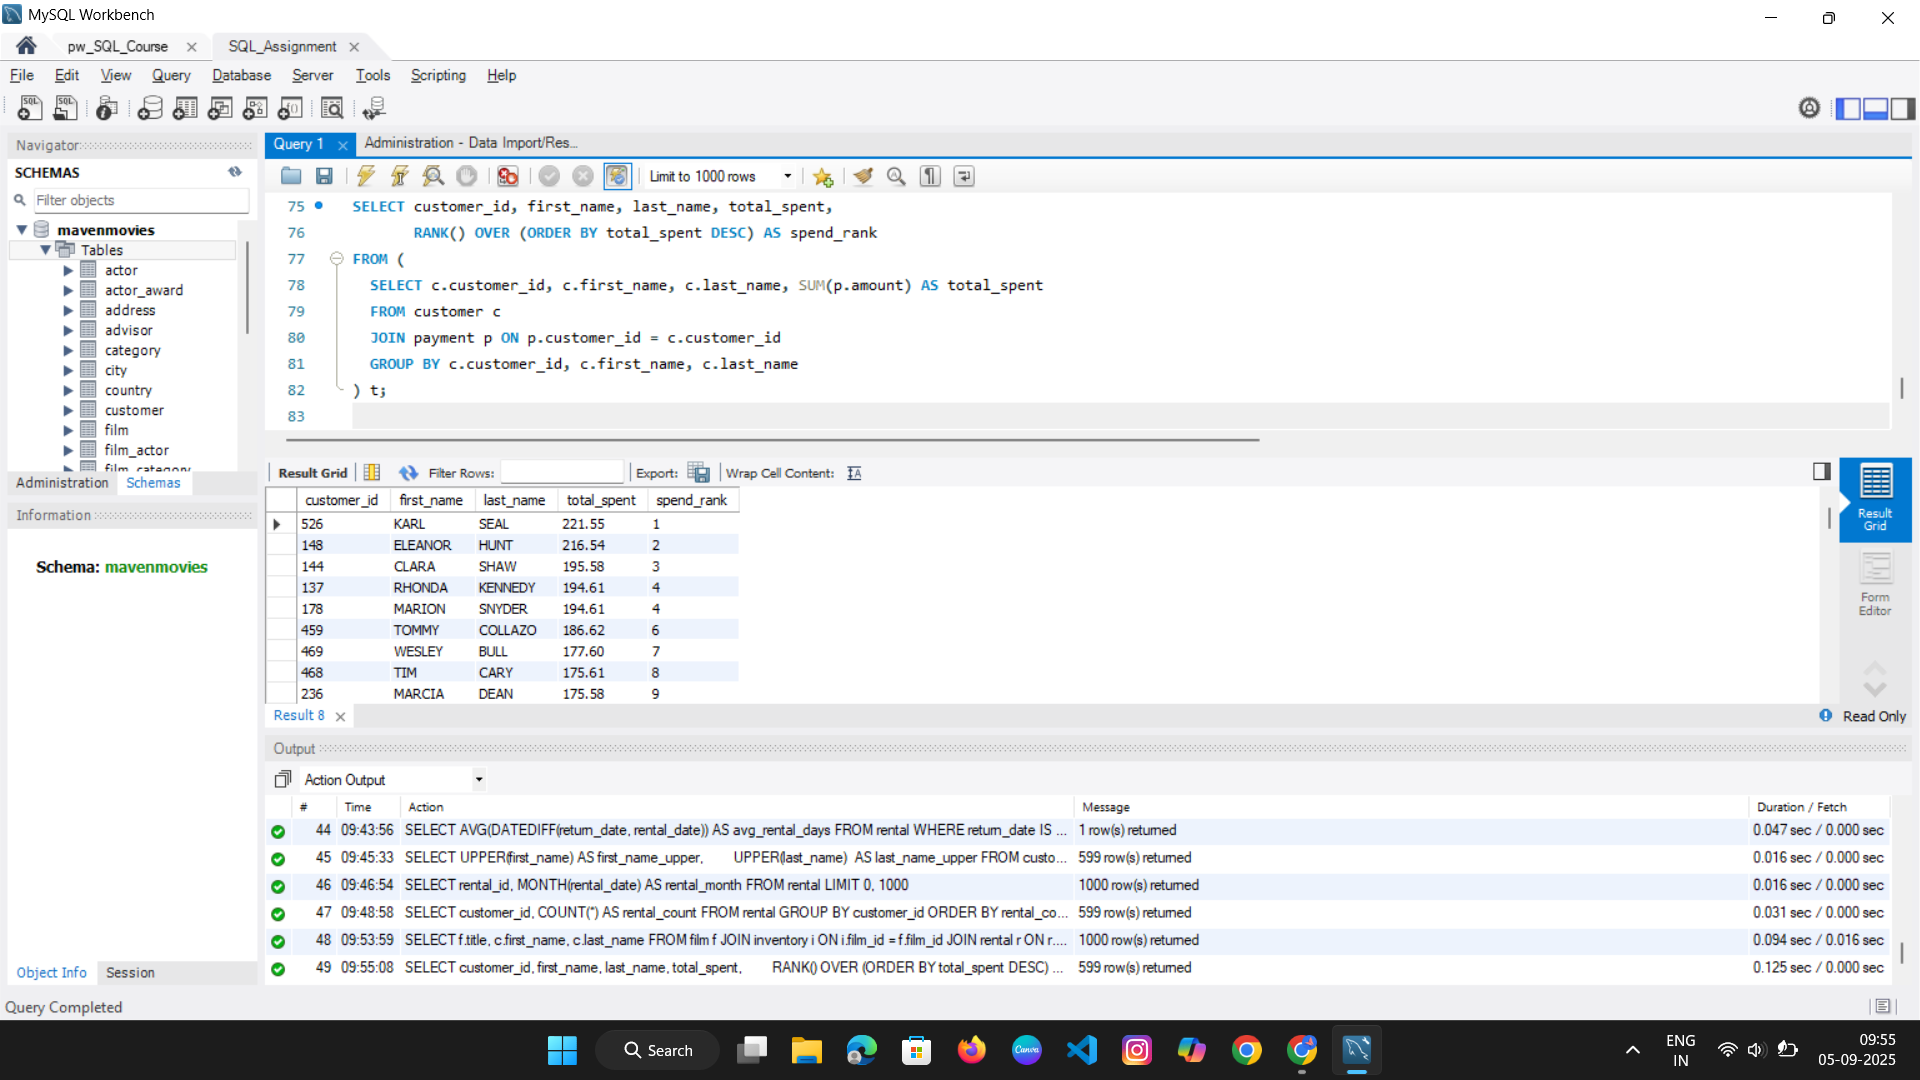

2. Calculate the cumulative revenue generated by each film over time.

In [ ]:
SELECT f.film_id, f.title, r.rental_date::date AS day, daily_rev,
       SUM(daily_rev) OVER (PARTITION BY f.film_id ORDER BY day) AS cum_revenue
FROM (
  SELECT i.film_id, DATE(r.rental_date) AS rental_date, SUM(p.amount) AS daily_rev
  FROM rental r
  JOIN payment p  ON p.rental_id   = r.rental_id
  JOIN inventory i ON i.inventory_id = r.inventory_id
  GROUP BY i.film_id, DATE(r.rental_date)
) x
JOIN film f ON f.film_id = x.film_id
ORDER BY f.film_id, day;


3. Determine the average rental duration for each film, considering films with similar lengths.

In [ ]:
SELECT f.film_id, f.title, f.length,
       AVG(DATEDIFF(r.return_date, r.rental_date))
         OVER (PARTITION BY f.length) AS avg_duration_for_same_length
FROM film f
JOIN inventory i ON i.film_id = f.film_id
JOIN rental r    ON r.inventory_id = i.inventory_id
WHERE r.return_date IS NOT NULL;


4. Identify the top 3 films in each category based on their rental counts.

In [ ]:
WITH counts AS (
  SELECT c.category_id, c.name AS category,
         f.film_id, f.title,
         COUNT(*) AS rental_count
  FROM category c
  JOIN film_category fc ON fc.category_id = c.category_id
  JOIN film f           ON f.film_id      = fc.film_id
  JOIN inventory i      ON i.film_id      = f.film_id
  JOIN rental r         ON r.inventory_id = i.inventory_id
  GROUP BY c.category_id, c.name, f.film_id, f.title
)
SELECT *
FROM (
  SELECT counts.*,
         DENSE_RANK() OVER (PARTITION BY category_id ORDER BY rental_count DESC) AS rk
  FROM counts
) t
WHERE rk <= 3
ORDER BY category, rental_count DESC;


5. Calculate the difference in rental counts between each customer's total rentals and the average rentals across all customers.

In [ ]:
WITH per_cust AS (
  SELECT customer_id, COUNT(*) AS rentals
  FROM rental
  GROUP BY customer_id
),
avg_all AS (
  SELECT AVG(rentals) AS avg_rentals FROM per_cust
)
SELECT p.customer_id, p.rentals,
       (p.rentals - a.avg_rentals) AS diff_from_avg
FROM per_cust p CROSS JOIN avg_all a
ORDER BY diff_from_avg DESC;


6. Find the monthly revenue trend for the entire rental store over time.

In [ ]:
SELECT DATE_FORMAT(payment_date, '%Y-%m') AS ym,
       SUM(amount) AS revenue,
       SUM(SUM(amount)) OVER (ORDER BY DATE_FORMAT(payment_date, '%Y-%m')) AS running_total
FROM payment
GROUP BY ym
ORDER BY ym;


7. Identify the customers whose total spending on rentals falls within the top 20% of all customers.

In [ ]:
WITH totals AS (
  SELECT customer_id, SUM(amount) AS total_spent
  FROM payment
  GROUP BY customer_id
),
ranked AS (
  SELECT t.*,
         CUME_DIST() OVER (ORDER BY total_spent DESC) AS cume
  FROM totals t
)
SELECT * FROM ranked
WHERE cume <= 0.20
ORDER BY total_spent DESC;


8. Calculate the running total of rentals per category, ordered by rental count.

In [ ]:
WITH cat_counts AS (
  SELECT c.name AS category, f.film_id, f.title, COUNT(*) AS rental_count
  FROM category c
  JOIN film_category fc ON fc.category_id = c.category_id
  JOIN film f           ON f.film_id      = fc.film_id
  JOIN inventory i      ON i.film_id      = f.film_id
  JOIN rental r         ON r.inventory_id = i.inventory_id
  GROUP BY c.name, f.film_id, f.title
)
SELECT category, film_id, title, rental_count,
       SUM(rental_count) OVER (PARTITION BY category ORDER BY rental_count DESC) AS running_total
FROM cat_counts
ORDER BY category, running_total;


9. Find the films that have been rented less than the average rental count for their respective categories.

In [ ]:
WITH film_counts AS (
  SELECT c.category_id, c.name AS category, f.film_id, f.title, COUNT(*) AS cnt
  FROM category c
  JOIN film_category fc ON fc.category_id = c.category_id
  JOIN film f           ON f.film_id      = fc.film_id
  JOIN inventory i      ON i.film_id      = f.film_id
  JOIN rental r         ON r.inventory_id = i.inventory_id
  GROUP BY c.category_id, c.name, f.film_id, f.title
),
cat_avg AS (
  SELECT category_id, AVG(cnt) AS avg_cnt
  FROM film_counts
  GROUP BY category_id
)
SELECT fc.category, fc.film_id, fc.title, fc.cnt, ca.avg_cnt
FROM film_counts fc
JOIN cat_avg ca ON ca.category_id = fc.category_id
WHERE fc.cnt < ca.avg_cnt
ORDER BY fc.category, fc.cnt;


10. Identify the top 5 months with the highest revenue and display the revenue generated in each month.

In [ ]:
WITH monthly AS (
  SELECT DATE_FORMAT(payment_date, '%Y-%m') AS ym, SUM(amount) AS revenue
  FROM payment
  GROUP BY ym
)
SELECT ym, revenue
FROM monthly
ORDER BY revenue DESC
LIMIT 5;


# **Normalisation & CTE**

Normal Form (1NF):

 a. Identify a table in the Sakila database that violates 1NF. Explain how you would normalize it to achieve 1NF.

If a table stores repeating groups (e.g., film_orders(order_id, film_ids CSV,
quantities CSV)), it violates 1NF.

Normalize by splitting into orders(order_id, ...) and order_items(order_id, film_id, quantity)—one fact per row, atomic values.

2. Second Normal Form (2NF):

 a. Choose a table in Sakila and describe how you would determine whether it is in 2NF.

 If it violates 2NF, explain the steps to normalize it.

A table with composite Primary Key is in 2NF if every non-key attribute depends on the whole key, not just part.

If enrollment(student_id, course_id, student_name) ⇒ student_name depends only on student_id (partial dependency) ⇒ not 2NF.

Fix: move student_name to students(student_id, student_name); keep enrollment(student_id, course_id, grade).

3. Third Normal Form (3NF):

 a. Identify a table in Sakila that violates 3NF. Describe the transitive dependencies

 present and outline the steps to normalize the table to 3NF

3NF requires no transitive dependencies: non-key attributes shouldn’t depend on other non-key attributes.

If film(film_id, title, category_id, category_name) ⇒ category_name depends on category_id (non-key) ⇒ not 3NF.

Fix: category(category_id, category_name) and keep only category_id in film.

4. Normalization Process:

 a. Take a specific table in Sakila and guide through the process of normalizing it from the initial

 unnormalized form up to at least 2NF.

Start with order(order_id, customer_id, customer_name, product_id, product_name, qty).

1NF: data atomic.

Split into: orders(order_id, customer_id), customers(customer_id, customer_name), order_items(order_id, product_id, qty), products(product_id, product_name).

6. CTE with Joins:

 a. Create a CTE that combines information from the film and language tables to display the film title,

 language name, and rental

In [ ]:
WITH film_lang AS (
  SELECT f.film_id, f.title, l.name AS language_name, f.rental_rate
  FROM film f
  JOIN language l ON l.language_id = f.language_id
)
SELECT * FROM film_lang ORDER BY title;


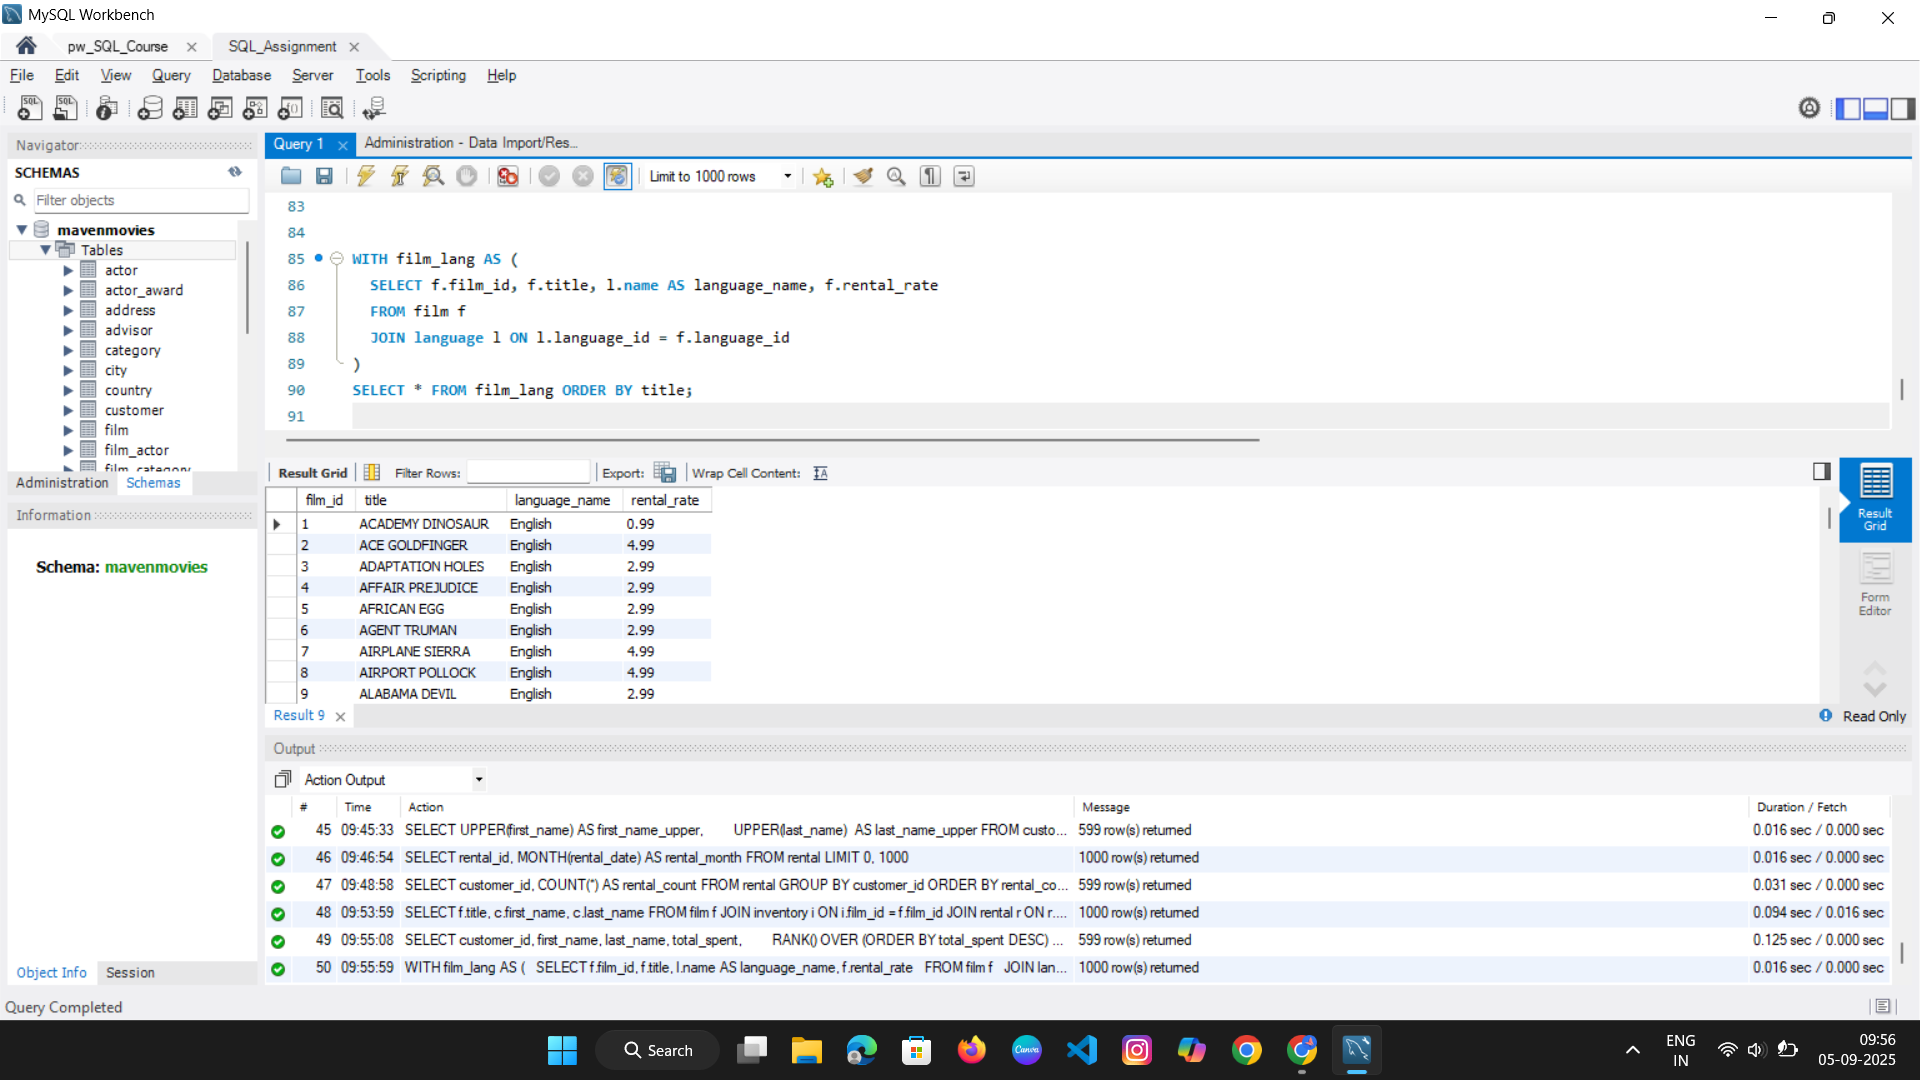

7. CTE for Aggregation:

 a. Write a query using a CTE to find the total revenue generated by each customer (sum of payments)

 from the customer and payment tab

In [ ]:
WITH cust_revenue AS (
  SELECT customer_id, SUM(amount) AS total_revenue
  FROM payment
  GROUP BY customer_id
)
SELECT * FROM cust_revenue ORDER BY total_revenue DESC;


8. CTE with Window Functions:

 a. Utilize a CTE with a window function to rank films based on their rental duration from the film table.

In [ ]:
WITH base AS (
  SELECT film_id, title, rental_duration
  FROM film
)
SELECT *, RANK() OVER (ORDER BY rental_duration DESC) AS duration_rank
FROM base;


9. CTE and Filtering:

 a. Create a CTE to list customers who have made more than two rentals, and then join this CTE with the customer table to retrieve additional customer details.

In [ ]:
WITH renter AS (
  SELECT customer_id, COUNT(*) AS rentals
  FROM rental
  GROUP BY customer_id
  HAVING COUNT(*) > 2
)
SELECT r.customer_id, c.first_name, c.last_name, r.rentals
FROM renter r
JOIN customer c ON c.customer_id = r.customer_id
ORDER BY r.rentals DESC;


10. CTE for Date Calculations:

 a. Write a query using a CTE to find the total number of rentals made each month, considering the rental_date from the rental table.

In [ ]:
WITH monthly AS (
  SELECT DATE_FORMAT(rental_date, '%Y-%m') AS ym, COUNT(*) AS rentals
  FROM rental
  GROUP BY ym
)
SELECT * FROM monthly ORDER BY ym;


11. CTE and Self-Join:

 a. Create a CTE to generate a report showing pairs of actors who have appeared in the same film

 together, using the film_actor table.

In [ ]:
WITH fa AS (
  SELECT film_id, actor_id FROM film_actor
)
SELECT a1.actor_id AS actor1, a2.actor_id AS actor2, fa1.film_id
FROM fa fa1
JOIN fa fa2 ON fa2.film_id = fa1.film_id AND fa2.actor_id > fa1.actor_id
JOIN actor a1 ON a1.actor_id = fa1.actor_id
JOIN actor a2 ON a2.actor_id = fa2.actor_id
ORDER BY fa1.film_id, actor1, actor2;


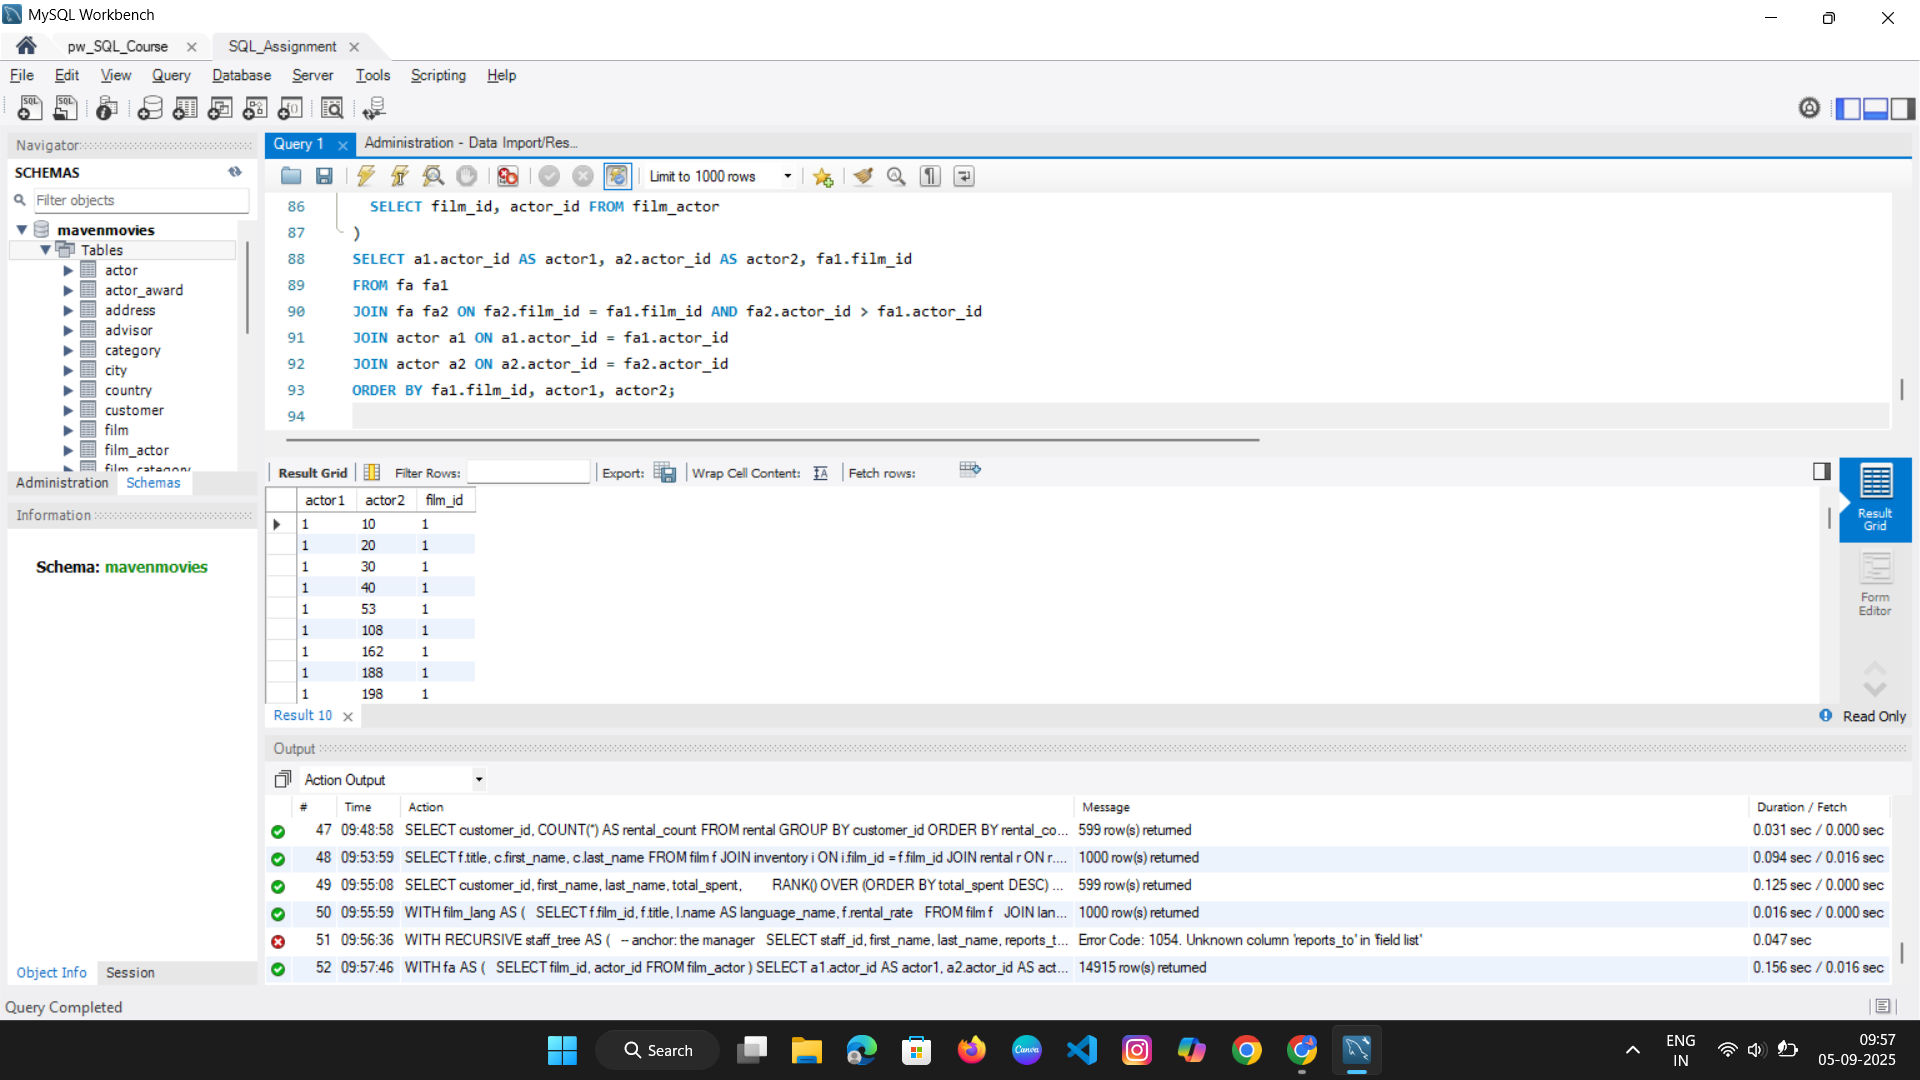

12. CTE for Recursive Search:

 a. Implement a recursive CTE to find all employees in the staff table who report to a specific manager,

 considering the reports_to column

In [ ]:
WITH RECURSIVE staff_tree AS (
  -- anchor: the manager
  SELECT staff_id, first_name, last_name, reports_to, 0 AS lvl
  FROM staff
  WHERE staff_id = @manager_id   -- set this variable to the manager you want

  UNION ALL

  -- recursive: direct reports
  SELECT s.staff_id, s.first_name, s.last_name, s.reports_to, st.lvl + 1
  FROM staff s
  JOIN staff_tree st ON s.reports_to = st.staff_id
)
SELECT * FROM staff_tree ORDER BY lvl, staff_id;
